# <img style="float: left; padding-right: 20px; width: 200px" src="https://raw.githubusercontent.com/raxlab/imt2200-data/main/media/logo.jpg">  IMT 2200 - Introducción a Ciencia de Datos
**Pontificia Universidad Católica de Chile**<br>
**Instituto de Ingeniería Matemática y Computacional**<br>
**Semestre 2025-S2**<br>
**Profesor:** Rodrigo A. Carrasco <br>

# <h1><center>Tarea 03: Exploración de datos </center></h1>

**Fecha de Entrega:** 28 de octubre de 2025, a las 23:59.

**Fecha de publicación**: 14 de octubre de 2025.

**Formato de entrega:** Notebook ejecutado y comentado (`.ipynb`) en el módulo de Tarea 03 habilitado en Canvas.

## Instrucciones

- Esta Tarea debe desarrollarse de manera totalmente *individual*, de acuerdo a lo establecido en la sección de Integridad Académica en el programa del curso.
- La Tarea debe ser desarrollada en lenguaje de programación Python y la entrega en formato Jupyter Notebook.
- El desarrollo del Notebook debe ser claro y ordenado, incluyendo anotaciones (markdown) y comentarios que permitan seguir fácilmente el código y los pasos implementados a los correctores, y siguiendo buenas prácticas de programación. La presentación y claridad del notebook y código forman parte de la evaluación de la tarea.
- Notebook **autocontenible** que:
   - Ejecute sin errores todas las celdas.
  - Contenga tanto el código como los comentarios y explicaciones necesarias.
  - Incluya visualizaciones claras y correctamente etiquetadas.
- No se aceptarán notebooks con celdas rotas o que dependan de rutas externas no indicadas en la tarea.

- Deben hacer sus consultas y comentarios sobre la Tarea a través del canal de Tareas en el Foro del curso en Canvas.

---

## 1. Objetivos

- Aplicar los conceptos iniciales de manejo de datos y análisis exploratorio vistos en clases.
- Practicar la lectura, limpieza y manipulación de datos en Python.
- Desarrollar habilidades para visualizar y describir patrones y tendencias en conjuntos de datos reales.
- Fomentar la capacidad de comunicar resultados de forma clara y fundamentada.

### 1.1 Objetivo educacional

Esta Tarea tiene como objetivo que los estudiantes desarrollen la capacidad de manejar algunas de las librerías centrales para el desarrollo de Ciencia de Datos, con foco en la lectura y exploración de datos. 

Para los ejercicios a continuación, usted deberá leer, inspeccionar, manipular y graficar conjuntos de datos en distintos formatos, de manera de responder las preguntas de cada parte de la Tarea.

### 1.2 Pregunta de ciencia de datos

En esta tarea vamos a analizar la distribución de vulneribilidad escolar para distintos establecimientos educacionales en Chile, desde enseñanza parvularia hasta enseñanza media. Específicamente, queremos entender cómo se comporta un índice de vulnerabilidad en relación a variables como ruralidad, tipo de dependencia y comuna del establecimiento.

---

## 2. Datos

En este estudio, trabajaremos con los resultados publicados anualmente sobre por la JUNAEB
sobre vulnerabilidad de establecimientos educacionales en todo el territorio nacional. Estos resultados están disponibles en la siguiente página web:

* Índices de Vulnerabilidad (JUNAEB): https://www.junaeb.cl/medicion-la-vulnerabilidad-ivm/

Adicionalmente, para visualizar las variables, utilizaremos los mapas vectoriales que disponibiliza la Biblioteca del Congreso Nacional (BCN):

* Mapoteca BCN: https://www.bcn.cl/siit/mapas_vectoriales/index_html

### 2.1 Descarga de datos y conceptos generales (1 punto)

Acceda a los links entregados y descargue el set de datos del **Índice de Vulnerabilidad Multidimensional de Establecimientos Educacionales** para el año 2025. Este debería ser un documento XLSX con múltiples pestañas, incluyendo entre estas un índice que describe las columnas presentes en la base de datos.
Descargue además los archivos correspondientes a la **División comunal: polígonos de las comunas de Chile**. Este se descarga en formato `.zip` y contiene archivos shapefile para visualizar las comunas del país.

Investigue sobre este índice y responda de manera concisa:

    ¿En qué consiste el IVM? ¿Qué rango de valores toma y qué significan?
    ¿Cómo se obtiene el IVM de un establecimiento educacional?

**Respuesta:**
1. El índice de vulnerabilidad multidimensional, IVM por sus siglas, captura, en una escala de 0 a 100, la estimación de qué tan vulnerable es un estudiante, mientras mayor sea el número, mayor es la vulnerabilidad. El IVM captura los factores más relevantes de vulnerarbilidad no observable, según la trayectoria del estudiante, se calcula anualmente en cuatro mediciones independientes, que corresponden a los 4 niveles educativos; parvularia, primer ciclo básico, segundo ciclo básico, y educación media. El IVM se ve afectado por factores como el contexto familiar, el ambiente, establecimiento educacional, entre otros. Se utiliza como orientación del estado del estudiante, pero también sirve para políticas públicas más generales, cmo el diseño, implementación, monitoreo y evaluación de programas relacionados con la educación. También permite realizar un seguimiento a la vulnerabilidad de establecimientos en regiones y comunes, tanto de modo general como por etapas educativas. Antiguamente se utilizaba la medición IVE-SINAE, que no no es comparable con la medición IVM.

2. El IVM de cada establecimiento lo calcula JUNAEB con el uso de registros administrativos y estadísticas públicas que posee el Estado de Chile, se consideran instituciones como; MINEDUC, MDS, SRCel, FONASA, SENAME, SINIM e INE. El cálculo es diferente para cada nivel, en la ponderación se considera información del estudiante proveniente de registros actuales e históricos, siendo alrededor del 70% de la ponderación proveniente de ifnormación entregada por respuestas en las encuestas de vulnerabilidad de JUNAEB, donde la mayor contribución es en las mediciones en las primeras etapas de la trayectoria escolar. También hay una imputación de información no disponible del estudiante, para esto se utiliza un método basado en distribuciones de probabilidad mediante chained equations. El cálculo contempla diferentes dimensiones y variables, que varían según el nivel educativo de cada etapa estudiantil. 


# 3. Lectura y limpieza de datos (1 punto)
3.1 Datos de establecimientos (0.5 puntos)

El archivo descargado contiene información sobre establecimientos de cuatro tipos: Parvularia, Primer Ciclo Básica, Segundo Ciclo Básica y Media. Cargue los datos de los establecimientos en cuatro DataFrames distintos.

Revise cada uno de sus sets de datos y haga un proceso de limpieza si lo considera necesario (manejo de valores nulos, duplicados, inválidos, transformación de tipos de datos, etc). De haberlos, identifique qué atributos son categóricos y transforme los tipos de columna de acuerdo a su decisión, mostrando todos los posibles valores de cada categoría.

Justifique todas sus decisiones, incluso si decide no realizar una limpieza o transformación.

Finalmente, responda:

    a. ¿Cuántos establecimientos tiene cada set de datos?
    b. ¿Cuánto espacio en memoria ocupan en total los 4 datasets?
    c. ¿Cuántos estudiantes fueron evaluados en todo el país para cada nivel de enseñanza para el año 2025?



In [1]:
import os # Para manejar las rutas de los directorios y ficheros en diferentes sistemas operativos.
import pandas as pd

root_dir = os.getcwd()
excel_establecimientos = os.path.join(root_dir, "data", "IVM_Establecimientos_2025-2.xlsx")

if not os.path.exists(excel_establecimientos): # Verificación de la ruta
    raise FileNotFoundError(f"El archivo {excel_establecimientos} no se encontró!")

# Primero que nada, definimos un diccionario con los nombres de las hojas, para poder iterar luego:
sheet_names = {
    "parvularia": "Parvularia",
    "basica_1": "1º Ciclo Básico",
    "basica_2": "2º Ciclo Básico",
    "media": "Media",
}

category_columns_names = {
    "parvularia": [],
    "basica_1": [],
    "basica_2": [],
    "media": [],
}

datasets = {} # Aquí almacenaremos los DF que iremos cargando en cada iteración.

for level, sheet in sheet_names.items():
    datasets[level] = pd.read_excel(excel_establecimientos, sheet_name=sheet)
    print(f"\n*** Recorriendo la sheet: {sheet}, cantidad de filas y columnas: {datasets[level].shape} ***")

    datasets[level].info(verbose=False)
    print("\n Primeras 3 filas de la sheet:")
    display(datasets[level].head(3))


    null_counts = datasets[level].isna().sum() # Conteo de entradas nulas en cada columna, tipo Series.
    print("Cantidad de valores nulos en las columnas:")
    display(null_counts[null_counts > 0].sort_values(ascending=False)) # Filtramos para mostrar solo columnas con nulos.
    if null_counts.sum() == 0:
        print("No hay columnas con valores nulos en el DF: ", level)

    # Hacemos una agregación para el conteo de duplicados exactos:
    duplicated_rows = datasets[level].duplicated().sum()
    print(f"Registros duplicados: {duplicated_rows}")


    ''' Aquí, el método nunique() de pandas.DataFrame, devuelve una Serie con la cantidad de
    valores únicos por cada columna del DF, excluyendo los NaN con dropna=True, la idea es
    identificar las columnas con pocas categorías distintas, para revisar si son categóricas.'''
    nunique = datasets[level].nunique(dropna=True)
    print("\n Columnas con n<=20 valores distintos en el DF:")
    cols_categoricals = nunique[nunique<=20]
    display(cols_categoricals)
    print("="*100)

    # Convertimos el index, que es el nombre de las columnas, a una lista de Python, y guardamos:
    category_columns_names[level] = cols_categoricals.index.tolist()

# Guardamos los DF del excel en variables independientes, como lo pide el enunciado.
df_parvularia = datasets["parvularia"]
df_basica_1_ciclo = datasets["basica_1"]
df_basica_2_ciclo = datasets["basica_2"]
df_media_ciclo = datasets["media"]


*** Recorriendo la sheet: Parvularia, cantidad de filas y columnas: (6163, 21) ***
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6163 entries, 0 to 6162
Columns: 21 entries, ID_RBD to IVM Derechos
dtypes: float64(7), int64(10), object(4)
memory usage: 1011.2+ KB

 Primeras 3 filas de la sheet:


,ID_RBD,DV_RBD,DS_NOM_ESTABLE,DS_TIPO_DEPENDENCIA,DS_RURALIDAD,ID_REGION_ESTABLE,ID_PROVINCIA_ESTABLE,ID_COMUNA_ESTABLE,DS_COMUNA_ESTABLE,N EVALUADO,...,IVM Bajo,IVM Medio,IVM Alto,IVM Muy Alto,IVM Salud,IVM CSE Familiar,IVM Estimulación y Apoyo,IVM Familia,IVM CSE Comunal,IVM Derechos
0,2,7,PARVULARIO LAS ESPIGUITAS,Servicio Local de Educación(SLE),Urbano,15,151,15101,Arica,75,...,41,18,10,6,24.494117,33.111049,34.732329,71.339647,13.929126,28.934927
1,8,6,COLEGIO INTEGRADO EDUARDO FREI MONTALVA,Servicio Local de Educación(SLE),Urbano,15,151,15101,Arica,29,...,6,9,8,6,33.627244,44.572505,44.160840,70.761131,13.941963,25.186786
2,9,4,ESCUELA REPUBLICA DE ISRAEL,Servicio Local de Educación(SLE),Urbano,15,151,15101,Arica,194,...,96,52,36,10,27.859852,35.035981,39.835498,70.725139,14.035447,26.995586


Cantidad de valores nulos en las columnas:


Series([], dtype: int64)

No hay columnas con valores nulos en el DF:  parvularia
Registros duplicados: 0

 Columnas con n<=20 valores distintos en el DF:


...

,ID_RBD,DV_RBD,DS_NOM_ESTABLE,DS_TIPO_DEPENDENCIA,DS_RURALIDAD,ID_REGION_ESTABLE,ID_PROVINCIA_ESTABLE,ID_COMUNA_ESTABLE,DS_COMUNA_ESTABLE,N EVALUADO,IVM Establecimiento,IVM Bajo,IVM Medio,IVM Alto,IVM Muy Alto
0,1,9,LICEO POLITECNICO ARICA,Servicio Local de Educación(SLE),Urbano,15,151,15101,Arica,674,27.530664,165,40,62,407
1,4,3,LICEO OCTAVIO PALMA PEREZ,Servicio Local de Educación(SLE),Urbano,15,151,15101,Arica,1224,14.893692,979,65,48,132
2,5,1,JOVINA NARANJO FERNANDEZ,Servicio Local de Educación(SLE),Urbano,15,151,15101,Arica,482,19.406501,270,49,39,124


Cantidad de valores nulos en las columnas:


Series([], dtype: int64)

No hay columnas con valores nulos en el DF:  media
Registros duplicados: 0

 Columnas con n<=20 valores distintos en el DF:


DV_RBD                 10
DS_TIPO_DEPENDENCIA     5
DS_RURALIDAD            2
ID_REGION_ESTABLE      16
dtype: int64

Ahora, realizamos el proceso de limpieza de manejo de valores nulos, duplicados, inválidos, transformación de tipos de datos, etc. También, identificaremos las columnas que debería ser de tipo category, y las transformamos a su tipo de dato correspondiente.

In [2]:
clean_datasets = {}

for level, dataframe in datasets.items():
    df_clean = dataframe.copy() # Copia de DF por valor, no por referencia en memoria (no cambia el original).
    print(f"\n*** Haciendo limpieza del DF: {level.upper()} ***")

    '''Aunque ya se verificó arriba, en la siguiente variable, almacenamos los valores nulos
    totales de cada DF, la idea es que aplicamos .sum() una vez para obtener los nulos por columna,
    y luego otra vez para obtener el total del objeto Pandas Series resultante luego de aplicar el
    primer método de agregación:'''
    null_total = int(df_clean.isna().sum().sum())
    
    if null_total == 0:
        print("No hay valores nulos.")
    else:
        print(f"Existen {null_total} valores nulos, eliminándolos...")
        df_clean = df_clean.dropna().reset_index(drop=True)
        print(".shape() del DF luego de eliminar valores nulos:", df_clean.shape)

    # Hacemos una eliminación de duplicados exactos:
    duplicates = int(df_clean.duplicated().sum())
    
    if duplicates > 0:
        print(f"Existen {duplicates} filas duplicadas, eliminando...")
        df_clean = df_clean.drop_duplicates().reset_index(drop=True)
    else:
        print("No hay filas duplicadas.")

    '''Hacemos uso de las columnas categóricas detectadas dinámicamente en la exploración
    de la celda anterior. La idea es convertir estas columnas a tipo 'category' en el DF:'''
    possible_categoricals_cols = category_columns_names.get(level, []) # Le pasamos una lista vacía si no hay, para evitar KeyError.
    converted_cols = []
    
    for column in possible_categoricals_cols:
        if column in df_clean.columns:
            df_clean[column] = df_clean[column].astype("category")
            converted_cols.append(column) # Agregamos la col convertida a la lista.

    '''Luego, si hay columnas convertidas, significa que efectivamente existen datos categóricos
    en este DataFrame, así que listamos sus categorías con el accesor .cat.'''
    if converted_cols:
        print("Columnas convertidas a tipo category, mostramos sus valores únicos:")
        for column in converted_cols:
            column_series = df_clean[column]
            # Seleccionamos la category de la columna:
            categories = column_series.cat.categories.tolist()
            print(f"  - {column}: {categories}")
    else:
        print("No hay columnas categóricas en este DF")

    clean_datasets[level] = df_clean
    print("Limpieza completada para este dataset.")
    print("-" * 90)

# Actualizamos las variables finales con las versiones limpias y tipificadas.
df_parvularia = clean_datasets["parvularia"]
df_basica_1_ciclo = clean_datasets["basica_1"]
df_basica_2_ciclo = clean_datasets["basica_2"]
df_media_ciclo = clean_datasets["media"]


*** Haciendo limpieza del DF: PARVULARIA ***
No hay valores nulos.
No hay filas duplicadas.
Columnas convertidas a tipo category, mostramos sus valores únicos:
  - DV_RBD: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
  - DS_TIPO_DEPENDENCIA: ['Corporación Municipal', 'Municipal DAEM', 'Particular Subvencionado', 'Servicio Local de Educación(SLE)']
  - DS_RURALIDAD: ['Rural', 'Urbano']
  - ID_REGION_ESTABLE: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16]
Limpieza completada para este dataset.
------------------------------------------------------------------------------------------

*** Haciendo limpieza del DF: BASICA_1 ***
No hay valores nulos.
No hay filas duplicadas.
Columnas convertidas a tipo category, mostramos sus valores únicos:
  - DV_RBD: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
  - DS_TIPO_DEPENDENCIA: ['Administración Delegada (C. P. 3166)', 'Corporación Municipal', 'Municipal DAEM', 'Particular Subvencionado', 'Servicio Local de Educación(SLE)']
  - DS_RURALIDAD: ['Rural', 'Urbano']
  -

Ahora, respondiendo a las preguntas específicas del enunciado, empezamos por la primera:

- **a. ¿Cuántos establecimientos tiene cada set de datos?**

In [3]:
# Volvemos a definir
niveles = {
    "Parvularia": df_parvularia,
    "Básica 1º ciclo": df_basica_1_ciclo,
    "Básica 2º ciclo": df_basica_2_ciclo,
    "Media": df_media_ciclo,
}

conteo_establecimientos = {} # Guardamos el conteo de establecimientos por cada nivel educacional.

for nivel, df in niveles.items():
    conteo_establecimientos[nivel] = len(df) # Conteo de filas por cada nivel.

establecimientos_por_nivel = pd.Series(conteo_establecimientos, name="Establecimientos")
print("\nCantidad de establecimientos por cada nivel educacional (que corresponde a cada set de datos):")
display(establecimientos_por_nivel)


Cantidad de establecimientos por cada nivel educacional (que corresponde a cada set de datos):


Parvularia         6163
Básica 1º ciclo    7082
Básica 2º ciclo    5662
Media              2618
Name: Establecimientos, dtype: int64

**b. ¿Cuánto espacio en memoria ocupan en total los 4 datasets?**

Para esta celda se utilizó un LLM para consultar la conversión de bytes a MB y confirmar el uso de memory_usage(deep=True) al sumar el tamaño de cada DF.

- prompt: "como convierto un valor en bytes a megabytes? Recuerda e indica la relación entre KB y MB y explicala, basada en el codigo de mis dataframe anteriores"

In [4]:
memoria_por_nivel = {}
# Calculamos el uso de memoria por DataFrame con un bucle explícito.
for nivel, df in niveles.items():
    memoria_por_nivel[nivel] = df.memory_usage(deep=True).sum()

memoria_por_nivel_series = pd.Series(memoria_por_nivel, name="Bytes")
display(memoria_por_nivel_series.to_frame())

memoria_total = memoria_por_nivel_series.sum()

""" Convertimos el total de bytes a megabytes usando potencias de 1024:
- 1 KB = 1024 bytes
- 1 MB = 1024 KB = 1024**2 bytes
Por eso, tenemos que dividir memoria_total entre 1024 elevado a 2
"""

print(f"Memoria total utilizada por los 4 DF: {memoria_total/1024**2:.2f} MB ({memoria_total:,} bytes)")

,Bytes
Parvularia,1673275
Básica 1º ciclo,2011602
Básica 2º ciclo,1253697
Media,590191


Memoria total utilizada por los 4 DF: 5.27 MB (5,528,765 bytes)


**c. ¿Cuántos estudiantes fueron evaluados en todo el país para cada nivel?**

In [5]:
totales_estudiantes = []

number_of_evaluated_students = 'N EVALUADO'

for nivel, df in niveles.items():
    if number_of_evaluated_students not in df.columns:
        raise KeyError(f"No existe la columna '{number_of_evaluated_students}' en el DF de nivel {nivel}")
    
    total_evaluados = int(df[number_of_evaluated_students].sum())

    totales_estudiantes.append({
        "Nivel educacional": nivel,
        "Nombre de columna": number_of_evaluated_students,
        "Estudiantes evaluados": total_evaluados,
    })

df_estudiantes_totales_eval = pd.DataFrame(totales_estudiantes)
print("\nCantidad de estudiantes evaluados por cada nivel educacional:")
display(df_estudiantes_totales_eval)


Cantidad de estudiantes evaluados por cada nivel educacional:


,Nivel educacional,Nombre de columna,Estudiantes evaluados
0,Parvularia,N EVALUADO,255506
1,Básica 1º ciclo,N EVALUADO,882881
2,Básica 2º ciclo,N EVALUADO,484540
3,Media,N EVALUADO,901899


### 3.2 Datos geográficos (0.5 puntos)

Cargue en un GeoDataFrame de GeoPandas la información de los polígonos de cada comuna del país.

Como realizamos en la Tarea pasada, puede transformar el Coordinate Reference System (CRS) a EPSG 4326, para tener la información de los puntos de los polígonos con latitud y longitud.

In [6]:
import geopandas as gpd
import matplotlib.pyplot as plt

shapefile_path = os.path.join(root_dir, "data", "comunas.shp")

# Prevención de errores si el directorio o fichero no existen:
if not os.path.exists(shapefile_path):
    raise FileNotFoundError(f"El fichero {shapefile_path} no se encontró")

gdf_comunas = gpd.read_file(shapefile_path)
gdf_comunas = gdf_comunas.to_crs(epsg=4326) # Convertimos el CRS a EPSG:4326, para tener lat/lon y poder graficar correctamente.

print('\nGeoDataFrame CRS:', gdf_comunas.crs)
print("\nPrimeras filas del GDF de comunas:")
display(gdf_comunas.head(3))


GeoDataFrame CRS: EPSG:4326

Primeras filas del GDF de comunas:


,objectid,shape_leng,dis_elec,cir_sena,cod_comuna,codregion,st_area_sh,st_length_,Region,Comuna,Provincia,geometry
0,48,170038.624165,16,8,6204,6,9.685774e+08,206184.271675,Región del Libertador Bernardo O'Higgins,Marchigüe,Cardenal Caro,"POLYGON ((-71.80071 -34.20728, -71.79992 -34.2..."
1,29,125730.104795,15,8,6102,6,4.157446e+08,151911.576827,Región del Libertador Bernardo O'Higgins,Codegua,Cachapoal,"POLYGON ((-70.35293 -33.95263, -70.35243 -33.9..."
2,30,63026.084422,15,8,6103,6,1.448565e+08,76355.326122,Región del Libertador Bernardo O'Higgins,Coinco,Cachapoal,"POLYGON ((-70.90058 -34.23703, -70.90063 -34.2..."


Hacemos una visualización simple de los polígonos de las comunas, para verificar:

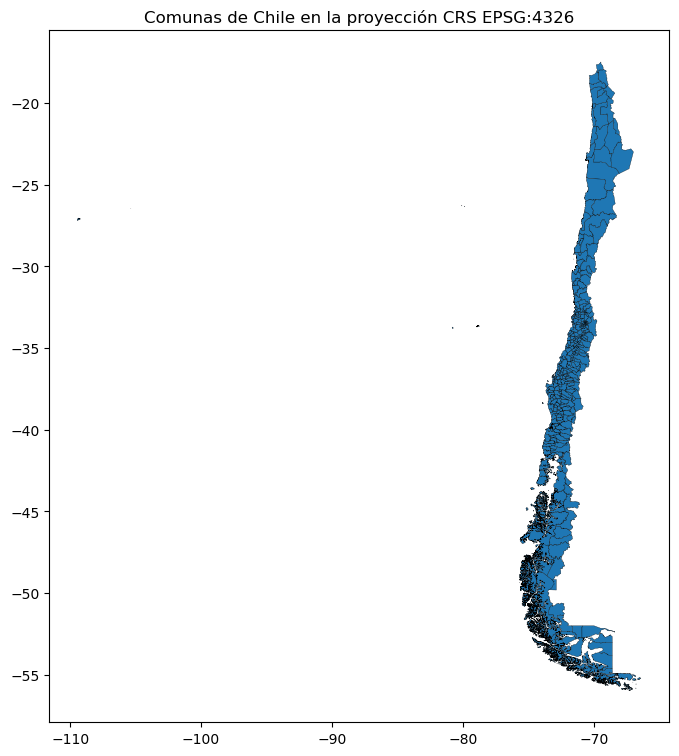

In [7]:
ax = gdf_comunas.plot(figsize=(8, 10), edgecolor="black", linewidth=0.2)
ax.set_title("Comunas de Chile en la proyección CRS EPSG:4326")
plt.show()

**a. ¿Cuál es la cantidad de establecimientos rurales vs urbanos según nivel de enseñanza?**

In [8]:
niveles_datos = {
    "Parvularia": df_parvularia,
    "Básica 1º ciclo": df_basica_1_ciclo,
    "Básica 2º ciclo": df_basica_2_ciclo,
    "Media": df_media_ciclo,
}

tabla_ruralidad = []

for nivel, df in niveles_datos.items():
    serie = df["DS_RURALIDAD"]
    conteo = serie.value_counts()
    rurales = int(conteo.get("Rural", 0))
    urbanos = int(conteo.get("Urbano", 0))
    
    tabla_ruralidad.append({
        "Nivel": nivel,
        "Establecimientos rurales": rurales,
        "Establecimientos urbanos": urbanos,
        "Total": rurales + urbanos,
    })

df_ruralidad_nivel = pd.DataFrame(tabla_ruralidad).set_index("Nivel") # El index se perdió al crear el DF, lo volvemos a poner.
display(df_ruralidad_nivel)

,Establecimientos rurales,Establecimientos urbanos,Total
Nivel,,,
Parvularia,1260,4903,6163
Básica 1º ciclo,2954,4128,7082
Básica 2º ciclo,1492,4170,5662
Media,169,2449,2618


En el output anterior, podemos ver una tabla comparativa de la cantidad total y específica de establecimientos educacionales rurales y urbanos, para cada nivel de enseñanza.

**b. ¿Cómo se distribuye el IVM según nivel de enseñanza y ruralidad?**

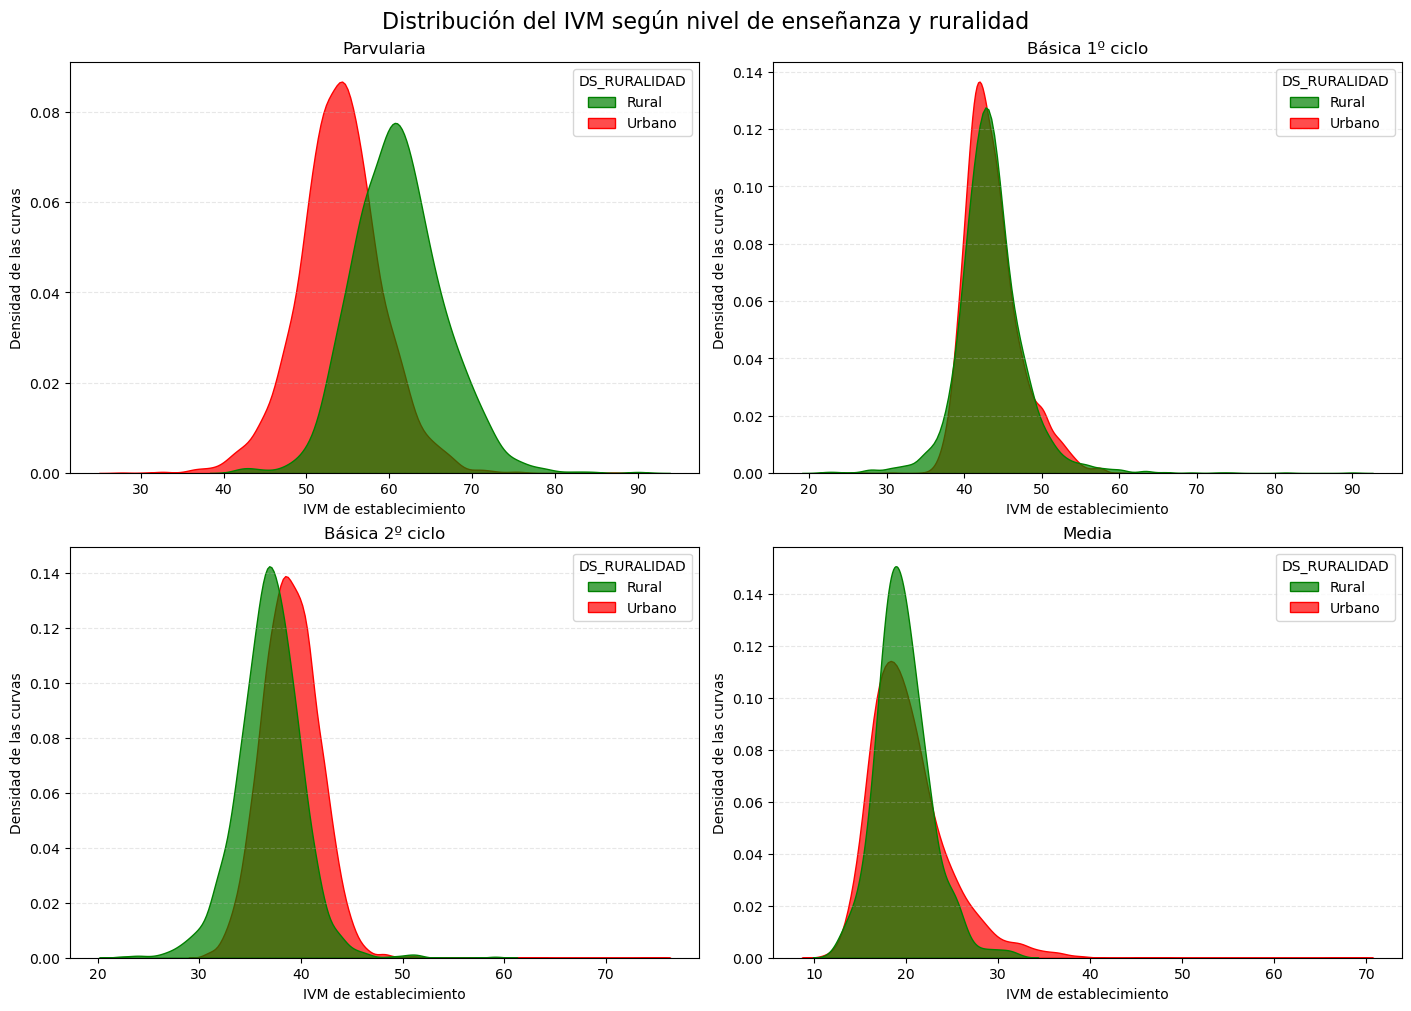

In [9]:
import seaborn as sns

# Distribución del IVM por nivel y ruralidad con Seaborn
fig, axes = plt.subplots(2, 2, figsize=(14, 10), constrained_layout=True)
niveles_lista = list(niveles_datos.items()) # Está en la celda anterior definido el mapeo
paleta = {"Urbano": "red", "Rural": "green"}

# El ciclo for fue generado con un LLM para poder recorrer los niveles y graficar
# pero todo el contenido interno fue generado por mí, el gráfico fue sacado de la documentación de Seaborn:
for ax, (nivel, df) in zip(axes.flatten(), niveles_lista):
    datos = df[["DS_RURALIDAD", "IVM Establecimiento"]].dropna()
    datos["DS_RURALIDAD"] = datos["DS_RURALIDAD"]

    sns.kdeplot(data=datos,x="IVM Establecimiento",hue="DS_RURALIDAD",fill=True,
        common_norm=False,
        palette=paleta, alpha=0.7,linewidth=1, ax=ax)
    
    ax.set_title(nivel)
    ax.set_xlabel("IVM de establecimiento")
    ax.set_ylabel("Densidad de las curvas")
    ax.grid(axis="y", linestyle="--", alpha=0.3)

fig.suptitle("Distribución del IVM según nivel de enseñanza y ruralidad", fontsize=16)
plt.show()

En la mayoría de los casos, la distribución indica que, para establecimientos urbanos, el IVM es menor, pero hay casos, como en el nivel de básica (segundo ciclo), en el que es al revés, aparentemente.

### 4.2 Tipo de establecimiento (0.7 pts)

* ¿Cómo es la distribución del IVM promedio de los establecimientos según tipo de dependencia y nivel de enseñanza? 

Realizamos una agrupación de cada nivel educativo, con la columna 'DS_TIPO_DEPENDENCIA', luego calculamos el IVM promedio, armamos una tabla y visualizamos.

Todo esto es suponiendo que el enunciado pide el promedio de los establecimietnos mediante el método .mean(), y no refiere al IVM de cada establecimiento sin ponderar.

In [10]:
resumen_dependencia = [] # IVM promedio por dependencia y nivel educativo

for nivel, df in niveles.items(): # Recordemos que 'niveles' es un diccionario con los DF procesados.
    
    if "DS_TIPO_DEPENDENCIA" not in df.columns or "IVM Establecimiento" not in df.columns:
        raise KeyError("Faltan una o más columnas necesarias para el procesamiento del IVM!")
    
    ''' Aquí, agruparemos todas las entradas que tengan el mismo valor en 'DS_TIPO_DEPENDENCIA', y luego
    calculamos el IVM promedio para cada agrupación obtenida, usando la columna 'IVM Establecimiento':'''
    
    promedio_dependencia = (
        df.groupby("DS_TIPO_DEPENDENCIA", observed=False)["IVM Establecimiento"]
        .mean()
        .reset_index() # Convertimos el Series a DF
        .rename(columns={"IVM Establecimiento": "IVM Promedio"})
    )
    
    # Dado que el DF 'promedio_dependencia' no tiene información del nivel educacional, la agregamos como columna:
    promedio_dependencia["Nivel Enseñanza"] = nivel
    resumen_dependencia.append(promedio_dependencia) # Agregamos el DF procesado a la lista, para luego graficar

ivm_dependencia = pd.concat(resumen_dependencia, ignore_index=True) # Juntamos todos los DF en uno solo (concatenamos)

''' Ordenamos el DF resultante, primero por nivel de enseñanza y luego por IVM promedio descendente, para cada
 tipo de dependencia educativa: '''
ivm_dependencia_sorted = ivm_dependencia.sort_values(["Nivel Enseñanza", "IVM Promedio"], ascending=[True, False])

print("\nIVM promedio por tipo de dependencia y nivel de enseñanza:")
display(ivm_dependencia_sorted)


IVM promedio por tipo de dependencia y nivel de enseñanza:


,DS_TIPO_DEPENDENCIA,IVM Promedio,Nivel Enseñanza
5,Corporación Municipal,45.013497,Básica 1º ciclo
8,Servicio Local de Educación(SLE),44.706152,Básica 1º ciclo
6,Municipal DAEM,43.656486,Básica 1º ciclo
7,Particular Subvencionado,42.723499,Básica 1º ciclo
4,Administración Delegada (C. P. 3166),40.222215,Básica 1º ciclo
9,Administración Delegada (C. P. 3166),40.522709,Básica 2º ciclo
10,Corporación Municipal,39.868568,Básica 2º ciclo
13,Servicio Local de Educación(SLE),38.605706,Básica 2º ciclo
12,Particular Subvencionado,38.498390,Básica 2º ciclo
11,Municipal DAEM,37.870933,Básica 2º ciclo


Ahora, vemos cuántas dependencias únicas tenemos

In [11]:
for nivel, df in niveles.items():
    print(f"{nivel} - dependencias educacionales únicas:", df["DS_TIPO_DEPENDENCIA"].nunique())
    print('='*100, '\n')

Parvularia - dependencias educacionales únicas: 4

Básica 1º ciclo - dependencias educacionales únicas: 5

Básica 2º ciclo - dependencias educacionales únicas: 5

Media - dependencias educacionales únicas: 5



Ahora, para visualizar mejor, realizaremos una visualización del IVM promedio, por tipo de dependencia y nivel ya agrupados, haciendo uso del DF unificado con el método .concat() en la celda previa.

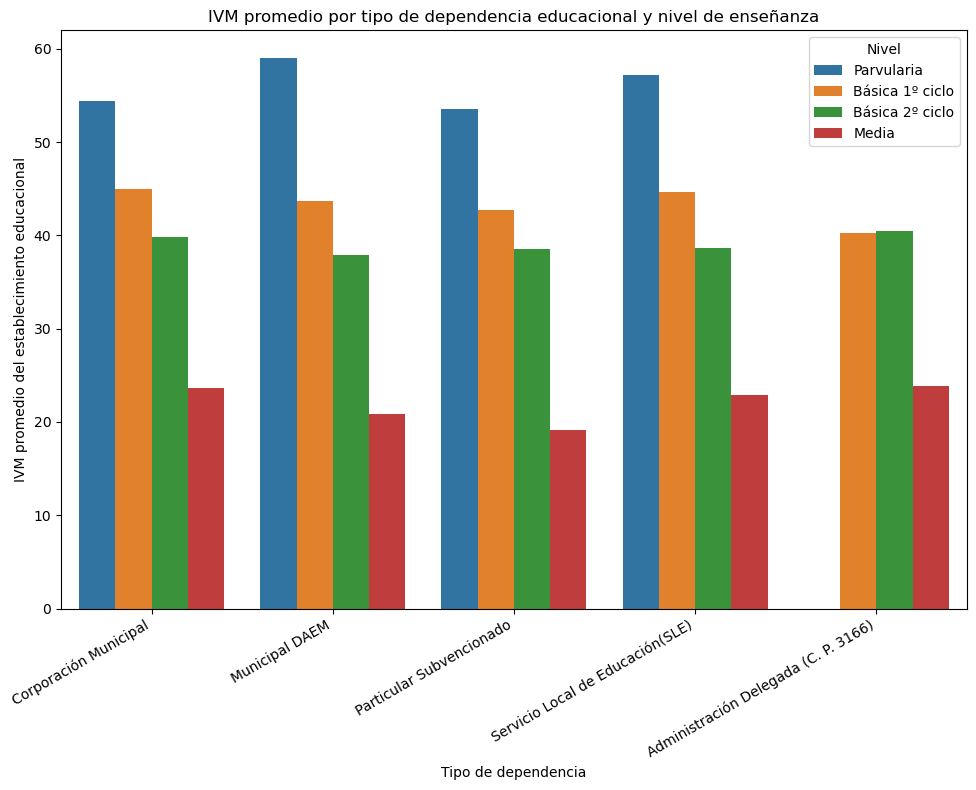

In [12]:
plt.figure(figsize=(10, 8))

sns.barplot(
    data=ivm_dependencia,
    x="DS_TIPO_DEPENDENCIA",
    y="IVM Promedio",
    hue="Nivel Enseñanza",
    errorbar=None,
    estimator="mean",
)

plt.title("IVM promedio por tipo de dependencia educacional y nivel de enseñanza")
plt.xlabel("Tipo de dependencia")
plt.ylabel("IVM promedio del establecimiento educacional")
plt.legend(title="Nivel")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

La tabla ayuda a visualizar el IVM promedio por tipo de dependencia educacional, donde podemos notar un patrón: los establecimientos municipales presentan valores de IVM promedio más altos en todos los ciclos, luego vienen los particulares subvencionados, y finalmente los particulares pagados, que tienen los menores valores, lo que indica que el índice de vulnerabilidad cataloga a los establecimientos municipales como los de mayor vulnerabilidad, en promedio.

### 4.3 Pregunta Bono: Dimensiones de vulnerabilidad (1 punto)

Para los niveles de enseñanza Parvularia y Básica Primer ciclo (1-4º), tenemos información sobre distintas dimensiones de que se utilizan para calcular el IVM, como condición socioeconómica familiar y comunal, salud, etc. 

* Para todo Chile, en promedio, ¿cuál es la dimensión con mayor puntaje de IVM para cada uno de estos dos niveles de enseñanza?

Viendo el output del DF, en celdas anteriores, que contiene las dimensiones que juegan un papel en el cálculo del IVM, podemos notar que esas dimensiones empiezan por 'IVM' en el nombre de sus columnas, así que haremos un bucle que tomará eso como indicador de que una columna es una dimensión, pero omitirá los IVM generales calculados que también vienen como columna. Luego, haremos el cálculo. 

In [13]:
niveles_de_interes = {
    "Parvularia": df_parvularia,
    "Básica 1º ciclo": df_basica_1_ciclo,
}

columnas_ivm_a_omitir = {
    "IVM Establecimiento",
    "IVM Bajo",
    "IVM Medio",
    "IVM Alto",
    "IVM Muy Alto",
}

def columnas_dimensiones_ivm(df):
    """Seleccionamos sólo las columnas con prefijo 'IVM', que no sean de 'columnas_ivm_a_omitir'. """
    valid_columns = []
    
    for columna in df.columns:
        if not columna.startswith("IVM"):
            continue
        if columna in columnas_ivm_a_omitir:
            continue
        if pd.api.types.is_numeric_dtype(df[columna]): # Filtramos sólo columnas numéricas
            valid_columns.append(columna)
    return valid_columns # Retornamos la lista de columnas válidas, para usarlas en la celda posterior

In [14]:
tablas_por_nivel = []

''' Ahora, vamos a iterar sobre los niveles de interés definidos en la celda anterior,
para luego calcular el IVM promedio por cada dimensión de ese nivel educacional específico.'''

for nivel, dataframe in niveles_de_interes.items():
    columnas_dimensiones = columnas_dimensiones_ivm(dataframe)
    
    if not columnas_dimensiones:
        raise ValueError("No se encontraron columnas con el prefijo 'IVM', o que cumplan los criterios!")
    
    promedios = dataframe[columnas_dimensiones].mean().sort_values(ascending=False) # Orden descendente del promedio.
    promedios.name = "IVM Promedio"  # Nombramos la Serie para que la columna no quede como 0

    df_promedios = (
        promedios
        .reset_index() # Convertimos la Serie a DF
        .rename(columns={"index": "Dimensión"})
    )

    df_promedios.insert(0, "Nivel Enseñanza", nivel)  # Agregamos la columna del nivel educacional en el primer lugar del DF
    tablas_por_nivel.append(df_promedios)

    higher_dimension = df_promedios.iloc[0] # Seleccionamos la primera fila, que es la dimensión con mayor IVM promedio.
    print(f"En {nivel}, la dimensión '{higher_dimension['Dimensión']}' tiene el mayor IVM promedio:\
        {higher_dimension['IVM Promedio']:.2f}")
    print("="*100, '\n')

ivm_dimensiones = pd.concat(tablas_por_nivel, ignore_index=True)
display(ivm_dimensiones)

En Parvularia, la dimensión 'IVM Familia' tiene el mayor IVM promedio:        70.67

En Básica 1º ciclo, la dimensión 'IVM CSE Familia' tiene el mayor IVM promedio:        54.39



,Nivel Enseñanza,Dimensión,IVM Promedio
0,Parvularia,IVM Familia,70.667085
1,Parvularia,IVM CSE Familiar,43.194210
2,Parvularia,IVM Estimulación y Apoyo,43.095565
3,Parvularia,IVM Salud,27.910199
4,Parvularia,IVM CSE Comunal,18.127686
5,Parvularia,IVM Derechos,14.211290
6,Básica 1º ciclo,IVM CSE Familia,54.390762
7,Básica 1º ciclo,IVM Salud,43.102350
8,Básica 1º ciclo,IVM Familiar,32.196868
9,Básica 1º ciclo,IVM CSE Comunal,22.728506


Respuesta y comentarios: Podemos notar que, gracias al código dinámico, podemos capturar diferentes dimensiones que afectan al IVM, siendo éstas dimensiones diferentes para los niveles educacionales de interés, con diferentes aportes al valor total calculado para cada nivel.

Como vemos, los resultados obtenidos son:

- En Parvularia, la dimensión 'IVM Familia' tiene el mayor IVM promedio: 70.67

- en Básica 1º ciclo, la dimensión 'IVM CSE Familia' tiene el mayor IVM promedio: 54.39

Lo que indica que, para ambos casos de los primeros niveles educativos, el contexto familiar tiene el mayor impacto en el índice de vulnerabilidad.


## 5. Agrupación de bases de datos (2 puntos)

El objetivo de esta sección será agrupar los establecimientos según la comuna en la que se encuentran para obtener un resumen general sobre la vulnerabilidad escolar en cada una de ellas. Al finalizar esta sección, tendremos un nuevo DataFrame `agg_comunal` que contenga, al menos, la siguiente información:

* Comuna (nombre y ID)
* Región (ID)
* Cantidad de establecimientos rurales de la comuna
* Cantidad de establecimientos urbanos de la comuna
* Cantidad total de establecimientos de la comuna
* Porcentaje de establecimientos rurales
* IVM Promedio Parvularia de la comuna
* IVM Promedio Básica Primer Ciclo de la comuna
* IVM Promedio Básica Segundo Ciclo de la comuna
* IVM Promedio Media de la comuna
* Objeto geometry de GeoPandas correspondiente al polígono de la comuna respectiva

Armaremos este DataFrame paso a paso.

### 5.1 Cálculo de IVM promedio por comuna (0.8 pts)

Primero, para cada uno sus 4 DataFrames, calcule el promedio de la columna `IVM Establecimiento` según comuna. Almacene este valor en una nueva columna llamada `IVM Promedio {NIVEL DE ENSEÑANZA}` (por ejemplo, para enseñanza parvularia, cree la columna `IVM Promedio Parvularia`).

Junte los 4 resultados que obtuvo en un solo DataFrame `ivm_comunal` que contenga:
* Comuna (nombre y ID)
* Región (ID)
* IVM Promedio Parvularia de la comuna
* IVM Promedio Básica Primer Ciclo de la comuna
* IVM Promedio Básica Segundo Ciclo de la comuna
* IVM Promedio Media de la comuna

Ponga siempre atención al tamaño de sus DataFrames: como estamos agrupando comunalmente, estos siempre debiesen tener una cantidad de filas igual a las comunas de Chile.

In [15]:
# Calculamos el IVM promedio por comuna para cada nivel educativo:
nombre_columna_por_nivel = {
    "Parvularia": "IVM Promedio Parvularia",
    "Básica 1º ciclo": "IVM Promedio Básica Primer Ciclo",
    "Básica 2º ciclo": "IVM Promedio Básica Segundo Ciclo",
    "Media": "IVM Promedio Media",
}

promedios_por_nivel = []
registros_temporal = []

for nivel, df in niveles.items():
    
    referencia_local = df[["ID_REGION_ESTABLE", "ID_COMUNA_ESTABLE", "DS_COMUNA_ESTABLE"]]\
    .drop_duplicates(subset=["ID_REGION_ESTABLE", "ID_COMUNA_ESTABLE"]) # Eliminamos posibles duplicados!
    
    registros_temporal.append(referencia_local)

    columna_promedio = nombre_columna_por_nivel.get(nivel, f"IVM Promedio {nivel}")
    
    # Agrupamos las columnas de una comuna dentro de cierta región, con el IVM del establecimiento, y sacamos el promedio
    promedio_ivm_comuna = (
        df.groupby(["ID_REGION_ESTABLE", "ID_COMUNA_ESTABLE"], observed=False)["IVM Establecimiento"].mean()
        .reset_index() # Convertimos en un DF
        .rename(columns={
                "ID_REGION_ESTABLE": "ID_REGION",
                "ID_COMUNA_ESTABLE": "ID_COMUNA",
                "IVM Establecimiento": columna_promedio,})
        )
    
    promedios_por_nivel.append(promedio_ivm_comuna)

# Concatenación realizada por un LLM (variable comunas_ref):
comunas_ref = (
    pd.concat(registros_temporal, ignore_index=True)
    .drop_duplicates(subset=["ID_REGION_ESTABLE", "ID_COMUNA_ESTABLE"])
    .rename(
        columns={
            "ID_REGION_ESTABLE": "ID_REGION",
            "ID_COMUNA_ESTABLE": "ID_COMUNA",
            "DS_COMUNA_ESTABLE": "DS_COMUNA",
        })
    )

Luego, debemos tipificar los tipos de dato a entero para evitar problemas, también hacemos una limpieza de datos faltantes:

In [16]:
comunas_ref = comunas_ref.dropna(subset=["ID_REGION", "ID_COMUNA"])

ivm_comunal = comunas_ref.copy() # Copiamos por valor para no alterar el valor del DF.

for promedio in promedios_por_nivel:
    promedio["ID_REGION"] = pd.to_numeric(promedio["ID_REGION"], errors="coerce")
    promedio["ID_COMUNA"] = pd.to_numeric(promedio["ID_COMUNA"], errors="coerce")
    promedio = promedio.dropna(subset=["ID_REGION", "ID_COMUNA"])
    ivm_comunal = ivm_comunal.merge(promedio, on=["ID_REGION", "ID_COMUNA"], how="left")

columnas_promedio = [nombre_columna_por_nivel[nivel] for nivel in niveles.keys()]
columnas_existentes = [col for col in columnas_promedio if col in ivm_comunal.columns]
columnas_orden = ["ID_REGION", "ID_COMUNA", "DS_COMUNA"] + columnas_existentes
ivm_comunal = ivm_comunal[columnas_orden].sort_values(["ID_REGION", "ID_COMUNA"]).reset_index(drop=True)

print(f"Comunas únicas: {comunas_ref.shape[0]}")
print(f"Filas en ivm_comunal: {ivm_comunal.shape[0]}")
print(f"Filas del DF ivm_comunal: {ivm_comunal.shape[0]}, columnas: {ivm_comunal.shape[1]}")

display(ivm_comunal.head(3))

Comunas únicas: 345
Filas en ivm_comunal: 345
Filas del DF ivm_comunal: 345, columnas: 7


,ID_REGION,ID_COMUNA,DS_COMUNA,IVM Promedio Parvularia,IVM Promedio Básica Primer Ciclo,IVM Promedio Básica Segundo Ciclo,IVM Promedio Media
0,1,1101,Iquique,50.882970,45.131982,39.182182,22.109517
1,1,1107,Alto Hospicio,55.419776,46.599904,41.289463,24.250219
2,1,1401,Pozo Almonte,59.804991,44.159905,35.386361,22.676408


In [17]:
# Validamos la consistencia del DataFrame comunal de promedios
total_comunas_origen = comunas_ref.shape[0]
total_ivm = ivm_comunal.shape[0]
print(f"Comunas únicas detectadas en los datos originales: {total_comunas_origen}")
print(f"Filas presentes en ivm_comunal: {total_ivm}")

if total_comunas_origen != total_ivm:
    print("ERROR: el número de filas no coincide!")
else:
    print("La cantidad de filas es correcta.")

duplicados = ivm_comunal.duplicated(subset=["ID_REGION", "ID_COMUNA"]).sum() # Sumamos todos los duplicados.

if duplicados:
    print(f"ERROR: se detectaron {duplicados} combinaciones duplicadas en el DF ivm_comunal!!")
else:
    print("No hay duplicados por ID_REGION e ID_COMUNA en el DF ivm_comunal.")

print(f"\nFilas finales en ivm_comunal: {ivm_comunal.shape[0]}, columnas: {ivm_comunal.shape[1]}")

Comunas únicas detectadas en los datos originales: 345
Filas presentes en ivm_comunal: 345
La cantidad de filas es correcta.
No hay duplicados por ID_REGION e ID_COMUNA en el DF ivm_comunal.

Filas finales en ivm_comunal: 345, columnas: 7


### 5.2 Establecimientos por comuna y ruralidad (0.8 pts)

Ahora contaremos la cantidad de establecimientos por comuna según ruralidad. Como buscamos la cantidad total de establecimientos, consideramos establecimientos de todos los niveles educacionales vistos. Para esto, combine los 4 DataFrames que cargó y genere un nuevo DataFrame `estab_comunal` que contenga:

* Comuna (ID)
* Cantidad de establecimientos rurales
* Cantidad de establecimientos urbanos
* Cantidad total de establecimientos
* Porcentaje de establecimientos rurales (Establecimientos rurales / Total establecimientos * 100)

Tenga en cuenta de que pueden aparecer establecimientos duplicados al combinar estos 4 DataFrames (por ejemplo, establecimientos que imparten múltiples niveles de enseñanza, desde 1º básico hasta 4º medio). Preocúpese de manejar estos casos antes de agrupar sus datos según ruralidad.

In [18]:
'''Esta función ha sido creada por un LLM, lo que hace es dinámicamente buscar
una columna en un DF, a partir de una lista de posibles nombres, de la variable col_map
definida más abajo, que también fue creada por un LLM, el prompt usado fue:
"escribe una función o forma de poder unificar el output de los df anteriores, esos 4
de 4 niveles educativos, o dame una idea de como hacerlo".'''
def pick_col(source, opciones, descripcion):
    columnas = source.columns if hasattr(source, "columns") else source
    normalizadas = {str(col).strip().upper(): col for col in columnas}
    for nombre in opciones:
        clave = str(nombre).strip().upper()
        if clave in normalizadas:
            return normalizadas[clave]
    raise KeyError(f"No se encontró una columna para {descripcion}. Probamos: {opciones}")

col_map = {
    "RBD": ["ID_RBD", "RBD", "CODIGO_RBD", "COD_RBD"],
    "ID_REGION": ["ID_REGION_ESTABLE", "ID_REGION", "COD_REGION", "CUT_REG"],
    "ID_COMUNA": ["ID_COMUNA_ESTABLE", "ID_COMUNA", "COD_COMUNA", "CUT_COM", "CODIGO_COMUNA"],
    "DS_COMUNA": ["DS_COMUNA_ESTABLE", "DS_COMUNA", "NOM_COMUNA", "NOM_COM"],
    "DS_RURALIDAD": ["DS_RURALIDAD", "RURALIDAD", "DS_RURALIDAD_RBD", "RURAL_RBD"],
}

registros = []

# Bucle for generado con un LLM, sirve para unificar los 4 DF en uno solo mediante la función pick_col:
for nivel, df in niveles.items():
    seleccion = {destino: pick_col(df, opciones, destino) for destino, opciones in col_map.items()}
    base = df[list(seleccion.values())].copy()
    base.columns = ["RBD", "ID_REGION", "ID_COMUNA", "DS_COMUNA", "DS_RURALIDAD"]
    base["FuenteNivel"] = nivel
    registros.append(base)


In [19]:
establecimientos = pd.concat(registros, ignore_index=True) # Creamos un nuevo DF concatenando los registros

for columna in ["RBD", "ID_REGION", "ID_COMUNA"]:
    establecimientos[columna] = pd.to_numeric(establecimientos[columna], errors="coerce") # Parseamos, por si acaso

establecimientos = establecimientos.dropna(subset=["RBD", "ID_REGION", "ID_COMUNA"]) # Limpiamos nulos.
establecimientos["RBD"] = establecimientos["RBD"].astype(int).astype(str) # Parseamos.
establecimientos[["ID_REGION", "ID_COMUNA"]] = establecimientos[["ID_REGION", "ID_COMUNA"]].astype(int) # Parseamos

establecimientos = establecimientos.drop_duplicates(subset=["RBD"]) # Eliminamos posibles duplicados, poco probable porque es RBD. 
rural_normalizado = establecimientos["DS_RURALIDAD"].astype(str).str.strip().str.upper() # Normalizamos strings y mayúsculas
establecimientos["es_rural"] = rural_normalizado.isin({"RURAL", "R"}).astype(int) # 1 si es rural, 0 si no lo es.

# Agrupamos los establecimientos por región y comuna, para obtener el conteo de los que son rurales: 
estab_comunal = (
    establecimientos.groupby(["ID_REGION", "ID_COMUNA"], observed=False)
    .agg(DS_COMUNA=("DS_COMUNA", "first"),
        establecimientos_rurales=("es_rural", "sum"),
        establecimientos_totales=("RBD", "count"))
    .reset_index() # Convertimos a DF
 )

# En las siguientes líneas, calculamos los establecimientos rurales, con la fórmula del enunciado 5.2
estab_comunal["establecimientos_urbanos"] = estab_comunal["establecimientos_totales"] - estab_comunal["establecimientos_rurales"]
estab_comunal["porcentaje_establecimientos_rurales"] =(
    estab_comunal["establecimientos_rurales"] / estab_comunal["establecimientos_totales"] * 100
).round(2)

estab_comunal = estab_comunal.sort_values(["ID_REGION", "ID_COMUNA"]).reset_index(drop=True)

print(f"Tabla de comunas, con {estab_comunal.shape[0]} filas y {estab_comunal.shape[1]} columnas. \n - Primeras 3 entradas:")
display(estab_comunal.head(3))

Tabla de comunas, con 345 filas y 7 columnas. 
 - Primeras 3 entradas:


,ID_REGION,ID_COMUNA,DS_COMUNA,establecimientos_rurales,establecimientos_totales,establecimientos_urbanos,porcentaje_establecimientos_rurales
0,1,1101,Iquique,3,84,81,3.57
1,1,1107,Alto Hospicio,3,44,41,6.82
2,1,1401,Pozo Almonte,12,12,0,100.00


### 5.3 Unión de bases de datos y polígonos (0.4 pts)

Finalmente, vamos a generar el DataFrame `agg_comunal` con la información de los dos previos DataFrames creados.
Combine la información de las dos secciones anteriores para crear su base de datos unificada. Por último, agregue la columna `geometry` con la información geográfica de cada comuna.

La siguiente celda, aunque la he cambiado casi a completitud, la he generado toda con un LLM, a excepción del final en # POSIBLES ENTRADAS SIN GEOMETRÍA. Entiendo si no tengo puntaje en esta celda, pero necesitaba completarlo de alguna forma u otra, para poder verificar que todo estuviera bien. Además, es necesaria la celda de geometry posteriormente, así que no pude dejar esta celda vacía por falta de tiempo.

In [20]:
# Función para normalizar códigos de comuna a enteros, realizada por un LLM:
# 'Crea una funcion que normalice el ID de comuna correctamente para mi DF'
def normaliza_codigo_entero(value):
    if pd.isna(value):
        return None
    digitos = "".join(ch for ch in str(value) if ch.isdigit())
    return int(digitos) if digitos else None

gdf_geom = gdf_comunas[['cod_comuna', "geometry"]].copy()
if "NOM_COM" in gdf_comunas.columns:
    gdf_geom["NOM_COM"] = gdf_comunas["NOM_COM"]

gdf_geom["_ID_COMUNA"] = gdf_geom['cod_comuna'].apply(normaliza_codigo_entero)
gdf_geom = gdf_geom.dropna(subset=["_ID_COMUNA"]).drop_duplicates(subset=["_ID_COMUNA"])

columnas_a_eliminar = ["DS_COMUNA"] if "DS_COMUNA" in estab_comunal.columns else []
agg_comunal = ivm_comunal.merge(
    estab_comunal.drop(columns=columnas_a_eliminar),
    on=["ID_REGION", "ID_COMUNA"],
    how="left",
)

columnas_extra = ["_ID_COMUNA", "geometry"]
if "NOM_COM" in gdf_geom.columns:
    columnas_extra.append("NOM_COM")

agg_comunal = agg_comunal.merge(
    gdf_geom[columnas_extra],
    left_on="ID_COMUNA",
    right_on="_ID_COMUNA",
    how="left")

agg_comunal = agg_comunal.drop(columns="_ID_COMUNA")

if "porcentaje_establecimientos_rurales" in agg_comunal.columns:
    agg_comunal["porcentaje_establecimientos_rurales"] = agg_comunal["porcentaje_establecimientos_rurales"].round(2)

columnas_ivm = [col for col in ivm_comunal.columns if col.startswith("IVM Promedio")]
columnas_estab = [
    col
    for col in [
        "establecimientos_rurales",
        "establecimientos_urbanos",
        "establecimientos_totales",
        "porcentaje_establecimientos_rurales",
    ]
    if col in agg_comunal.columns
]
columnas_orden = ["ID_REGION", "ID_COMUNA", "DS_COMUNA"] + columnas_ivm + columnas_estab
if "NOM_COM" in agg_comunal.columns:
    columnas_orden.append("NOM_COM")
columnas_orden.append("geometry")

agg_comunal = agg_comunal[columnas_orden]
agg_comunal = agg_comunal.sort_values(["ID_REGION", "ID_COMUNA"]).reset_index(drop=True)
agg_comunal = gpd.GeoDataFrame(agg_comunal, geometry="geometry", crs=gdf_comunas.crs)

# POSIBLES ENTRADAS SIN GEOMETRÍA:
faltantes_geometry = agg_comunal["geometry"].isna().sum()
if faltantes_geometry:
    print(f"ERROR: {faltantes_geometry} comunas no tienen geometry!!")
else:
    print("Todas las comunas poseen geometry")

print(f"DF de comunas final listo: {agg_comunal.shape[0]} filas, {agg_comunal.shape[1]} columnas")
display(agg_comunal.head(2))

Todas las comunas poseen geometry
DF de comunas final listo: 345 filas, 12 columnas


,ID_REGION,ID_COMUNA,DS_COMUNA,IVM Promedio Parvularia,IVM Promedio Básica Primer Ciclo,IVM Promedio Básica Segundo Ciclo,IVM Promedio Media,establecimientos_rurales,establecimientos_urbanos,establecimientos_totales,porcentaje_establecimientos_rurales,geometry
0,1,1101,Iquique,50.882970,45.131982,39.182182,22.109517,3,81,84,3.57,"MULTIPOLYGON (((-70.16034 -20.2107, -70.16031 ..."
1,1,1107,Alto Hospicio,55.419776,46.599904,41.289463,24.250219,3,41,44,6.82,"POLYGON ((-69.89186 -20.06942, -69.89629 -20.1..."


## 6. Análisis de vulnerabilidad por comuna (1.5 puntos)

### 6.1 Mapa de calor (0.8 pts)

Genere mapas de calor de las comunas de Chile según el IVM promedio de los establecimientos educacionales. Realice esto para cada etapa de enseñanza (Parvularia, Básica 1, Básica 2 y Media). Analice y comente sus resultados:
* ¿Cómo se diferencia la vulnerabilidad en distintos sectores del país según nivel de enseñanza?

Vamos a generar mapas de coropletas para el IVM promedio previamente calculados, y los vamos a mostrar y guardar individualmente, porque agrupados todos juntos resulta en una dificultad para distinguir de buena manera.

Hay una leyenda en la derecha de cada visualización, que indica si el promedio del IVM en esa comuna es un numero alto o bajo. 

Imagen generada y guardada en: c:\Users\pluta\Desktop\Introducción a la Ciencia de Datos\TAREA3\generated_images\ivm_promedio_IVM Promedio Parvularia.png


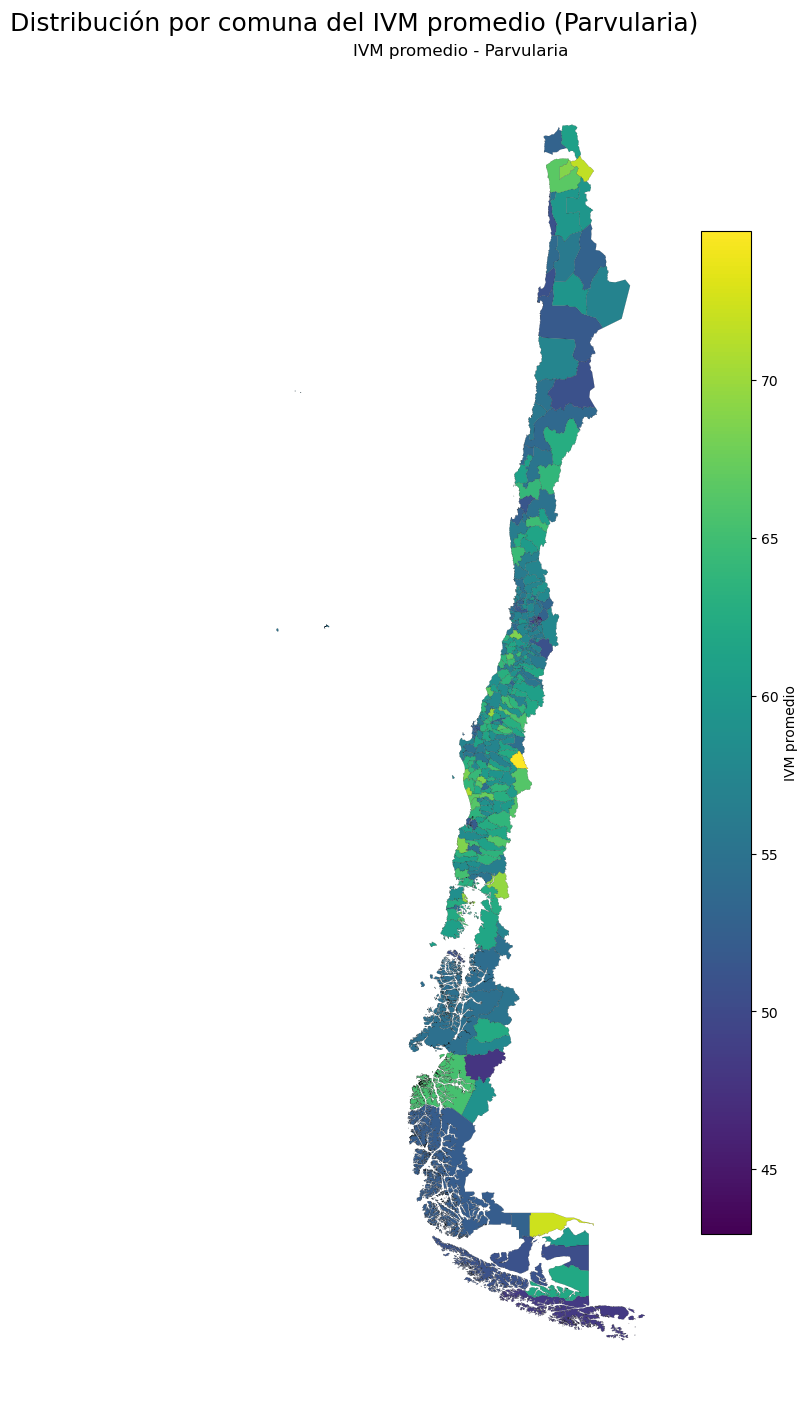

Imagen generada y guardada en: c:\Users\pluta\Desktop\Introducción a la Ciencia de Datos\TAREA3\generated_images\ivm_promedio_IVM Promedio Básica Primer Ciclo.png


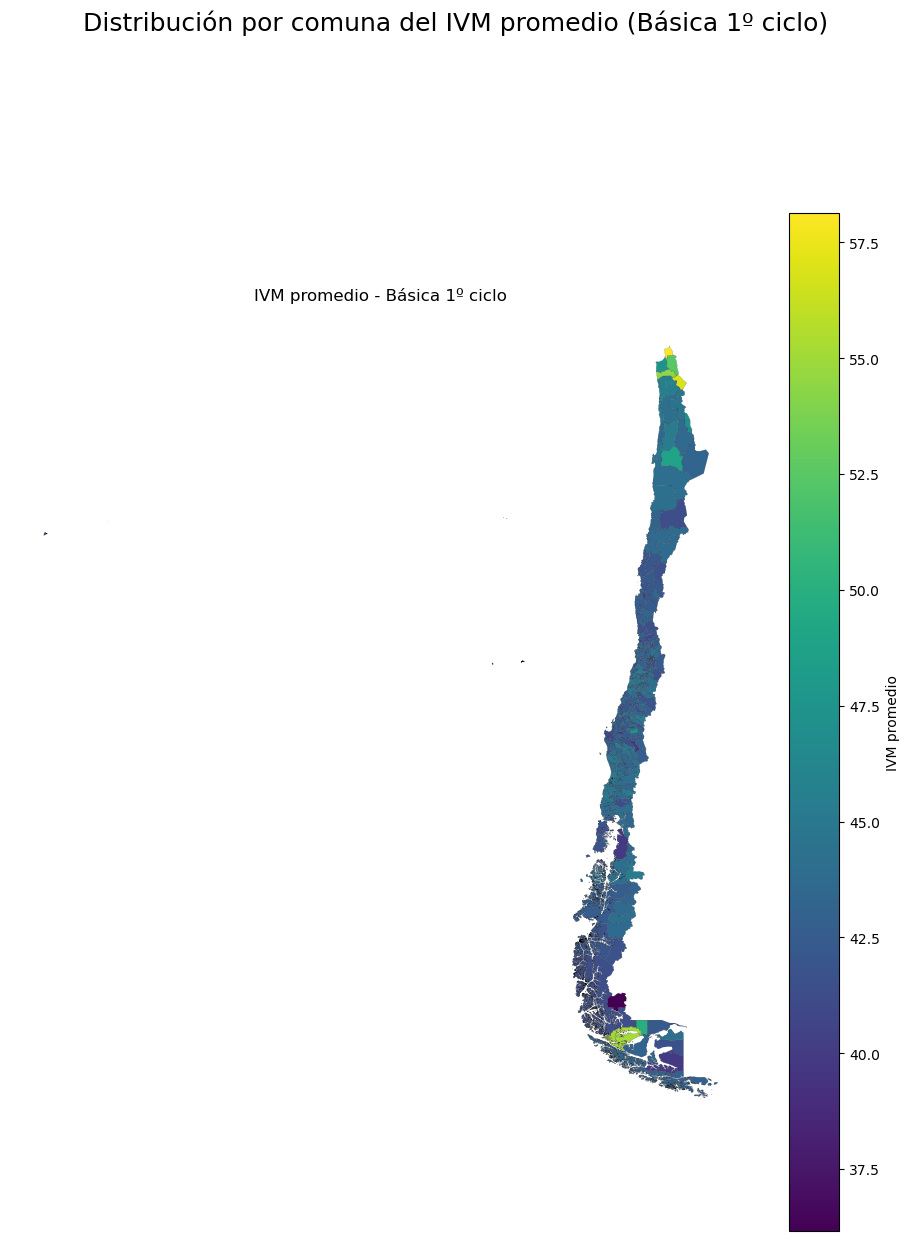

Imagen generada y guardada en: c:\Users\pluta\Desktop\Introducción a la Ciencia de Datos\TAREA3\generated_images\ivm_promedio_IVM Promedio Básica Segundo Ciclo.png


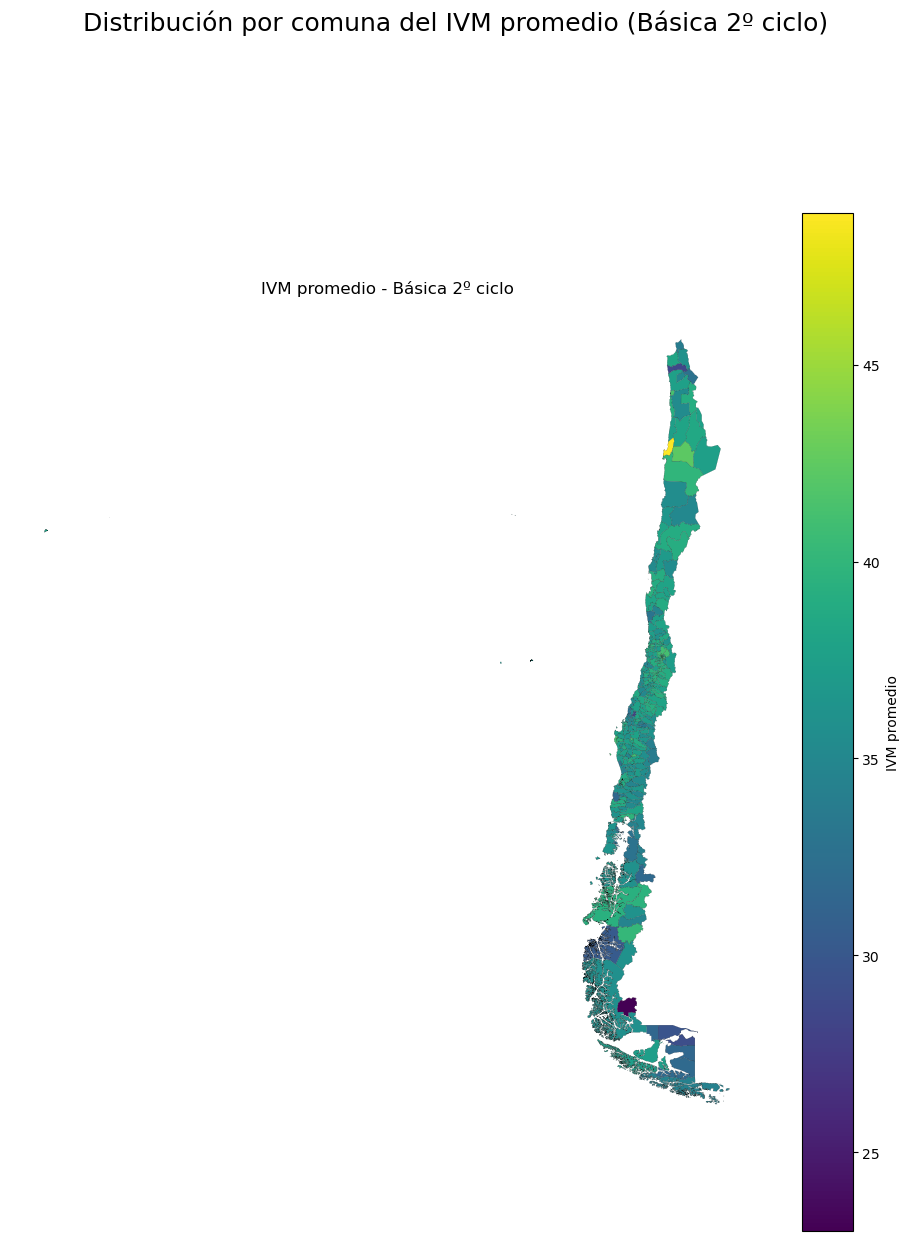

Imagen generada y guardada en: c:\Users\pluta\Desktop\Introducción a la Ciencia de Datos\TAREA3\generated_images\ivm_promedio_IVM Promedio Media.png


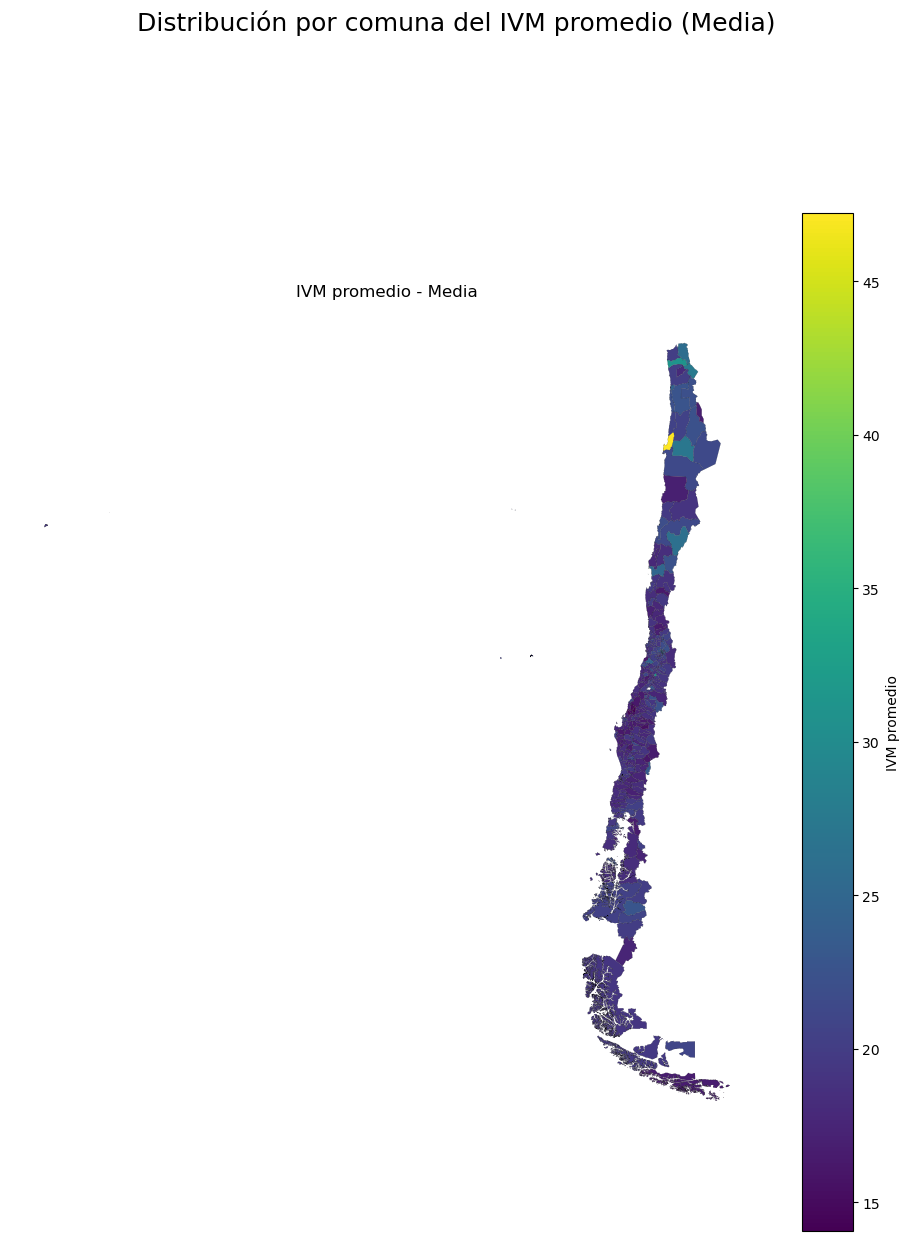

Valores estadísticos del IVM promedio:


,Mínimo,Percentil 25,Mediana,Percentil 75,Máximo
Nivel,,,,,
Parvularia,42.95,54.57,57.89,61.71,74.73
Básica 1º ciclo,36.16,42.33,43.29,44.14,58.14
Básica 2º ciclo,23.00,36.10,37.63,38.89,48.87
Media,14.07,17.94,19.16,20.51,47.23


In [21]:
# Mapas de coropleta del IVM promedio por nivel educativo, en cada comuna del país:
niveles_ivm_to_plot = [
    ("IVM Promedio Parvularia", "Parvularia"),
    ("IVM Promedio Básica Primer Ciclo", "Básica 1º ciclo"),
    ("IVM Promedio Básica Segundo Ciclo", "Básica 2º ciclo"),
    ("IVM Promedio Media", "Media")]

#Verificamos que las columnas de la variable niveles_ivm_plot estén en el agregado de comunas generado anteriormente:
columnas_disponibles = [col for col, _ in niveles_ivm_to_plot if col in agg_comunal.columns]

output_directory = os.path.join(root_dir, "generated_images")
os.makedirs(output_directory, exist_ok=True)

resumen_ivm = []
for columna_ivm, nombre_mapa in niveles_ivm_to_plot:
    
    if columna_ivm not in agg_comunal.columns:
        continue # Significa que 

    datos_nivel = agg_comunal.dropna(subset=[columna_ivm]) # Limpiamos los NaN
    if datos_nivel.empty:
        continue

    # Creación del plot (visualización) del IVM promedio según las comunas del país:
    fig, ax = plt.subplots(figsize=(9, 14), constrained_layout=True)
    datos_nivel.plot(
        column=columna_ivm,
        ax=ax,
        cmap="viridis",
        linewidth=0.08,
        edgecolor="black",
        legend=True,
        legend_kwds={"label": "IVM promedio", "shrink": 0.75},
    )
    ax.set_title(f"IVM promedio - {nombre_mapa}")
    ax.set_axis_off()
    fig.suptitle(f"Distribución por comuna del IVM promedio ({nombre_mapa})", fontsize=18)
    
    path_generated_image = os.path.join(output_directory, f"ivm_promedio_{columna_ivm}.png")
    fig.savefig(path_generated_image, dpi=600, bbox_inches="tight")
    print(f"Imagen generada y guardada en: {path_generated_image}")
    plt.show()
    
    # Cálculo de quartiles generado por un LLM, para poder generar un DF con esto, y mostrarlo al final de la celda:
    serie = datos_nivel[columna_ivm]
    resumen_ivm.append({
        "Nivel": nombre_mapa,
        "Mínimo": serie.min(),
        "Percentil 25": serie.quantile(0.25),
        "Mediana": serie.median(),
        "Percentil 75": serie.quantile(0.75),
        "Máximo": serie.max(),
    })

if resumen_ivm:
    tabla_resumen_ivm = pd.DataFrame(resumen_ivm).set_index("Nivel")
    print('Valores estadísticos del IVM promedio:')
    display(tabla_resumen_ivm.round(2))
else:
    print("ERROR: No se pudo construir el DF estadístico del IVM por nivel educativo!")

En los mapas se aprecia cómo varía el IVM promedio entre comunas para cada nivel educativo. Las escalas numéricas mostradas bajo cada subgráfico permiten identificar los focos de mayor vulnerabilidad, mientras que la tabla resume los rangos típicos (mínimo, cuartiles y máximo). Las comunas que comparten tonalidades más oscuras concentran IVM más altos, de modo que contrastar los paneles facilita detectar si un nivel exhibe sistemáticamente mayores puntajes que los demás.

### 6.2 Relación entre ruralidad comunal y vulnerabilidad (0.7 pts)

En la sección **5.2** definimos el **porcentaje de ruralidad** de cada comuna según la cantidad de establecimientos rurales en cada una. Analice y visualice los datos en `agg_comunal` para responder la siguiente pregunta:

* ¿Hay alguna correlación entre el IVM promedio y el porcentaje de ruralidad en las comunas de Chile?

Como ya tenemos el DF `agg_comunal`, lo podemos usar para, mediante el coeficiente de de Pearson, medir la correlación entre el IVM promedio y el porcentaje de ruralidad, las entradas serán el IVM promedio y el porcentaje de ruralidad del dataset. Si el porcentaje de correlación es de magnitud 1, significa una alineación perfecta, el signo indica si la correlación es negativa o positiva, los valores entre -1 y 1 nos entregan información sobre la correlación de las dos variables.

dataset agg_comunal: 



,ID_REGION,ID_COMUNA,DS_COMUNA,IVM Promedio Parvularia,IVM Promedio Básica Primer Ciclo,IVM Promedio Básica Segundo Ciclo,IVM Promedio Media,establecimientos_rurales,establecimientos_urbanos,establecimientos_totales,porcentaje_establecimientos_rurales,geometry
0,1,1101,Iquique,50.88297,45.131982,39.182182,22.109517,3,81,84,3.57,"MULTIPOLYGON (((-70.16034 -20.2107, -70.16031 ..."


,Coeficiente Pearson,Comunas consideradas
Nivel,,
Parvularia,0.764,338
Básica 1º ciclo,0.046,345
Básica 2º ciclo,-0.607,344
Media,-0.266,335


Parvularia: correlación alta positiva (ρ = 0.764, n = 338.0)
Básica 1º ciclo: correlación casi nula positiva (ρ = 0.046, n = 345.0)
Básica 2º ciclo: correlación alta negativa (ρ = -0.607, n = 344.0)
Media: correlación baja negativa (ρ = -0.266, n = 335.0)


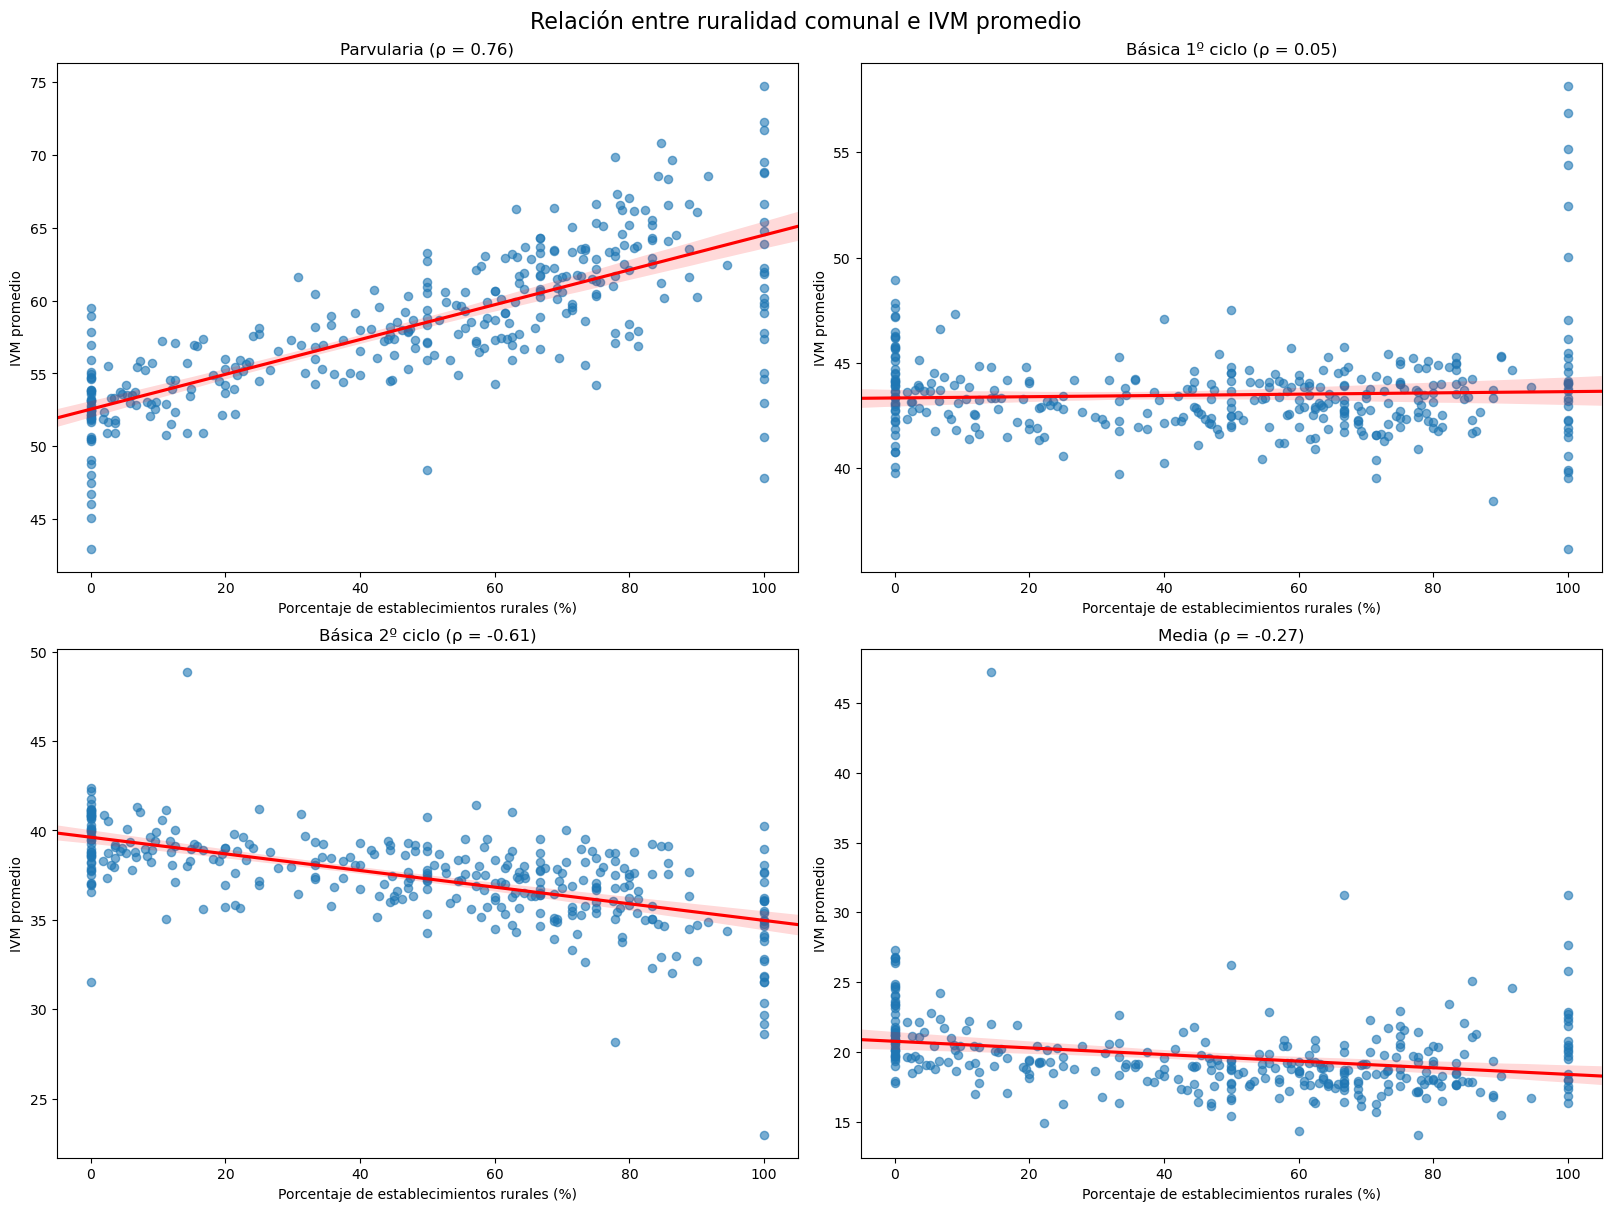

In [22]:
print('dataset agg_comunal:','\n')
display(agg_comunal.head(1)) # Vemos la primera fila, sólo para verificar las columnas del dataset

columna_ruralidad = "porcentaje_establecimientos_rurales"

fig, axes = plt.subplots(2, 2, figsize=(16, 12), constrained_layout=True) # Definimos la visualización
correlaciones = []

# Aquí, la función zip para emparejar los ejes fue generada por un LLM:
for (columna_ivm, nombre_nivel), ax in zip(niveles_ivm_to_plot, axes.flat):
    
    # Limpiamos posibles los NaN en las variables a correlacionar:
    datos = agg_comunal[[columna_ruralidad, columna_ivm]].dropna()

    corr = datos[columna_ivm].corr(datos[columna_ruralidad]) # Método de pandas para correlacionar variables.
    
    correlaciones.append({
        "Nivel": nombre_nivel,
        "Coeficiente Pearson": corr,
        "Comunas consideradas": len(datos),
    })
    
    # Graficamos, con la librería Seaborn
    sns.regplot(
        data=datos,
        x='porcentaje_establecimientos_rurales',
        y=columna_ivm,
        ax=ax,
        scatter_kws={"alpha": 0.6, "s": 35},
        line_kws={"color": "red"},
        truncate=False,
    )
    ax.set_title(f"{nombre_nivel} (ρ = {corr:.2f})")
    ax.set_xlabel("Porcentaje de establecimientos rurales (%)")
    ax.set_ylabel("IVM promedio")

fig.suptitle("Relación entre ruralidad comunal e IVM promedio", fontsize=16)

if correlaciones:
    
    df_correlaciones = pd.DataFrame(correlaciones).set_index("Nivel") # Armamos un DF con las correlaciones
    display(df_correlaciones.round({"Coeficiente Pearson": 3}))
    
    for nivel, row in df_correlaciones.round({"Coeficiente Pearson": 3}).iterrows():
        coef = row["Coeficiente Pearson"]
        magnitud = abs(coef)
        if magnitud < 0.1:
            interpretacion = "correlación casi nula"
        elif magnitud < 0.3:
            interpretacion = "correlación baja"
        elif magnitud < 0.5:
            interpretacion = "correlación intermedia"
        else:
            interpretacion = "correlación alta"
        
        tendencia_corr = "positiva" if coef >= 0 else "negativa"
        
        print(f"{nivel}: {interpretacion} {tendencia_corr} (ρ = {coef:.3f}, n = {row['Comunas consideradas']})")
else:
    print("ERROR: No se pudieron calcular las correlaciones correctamente!")

* ¿Hay alguna correlación entre el IVM promedio y el porcentaje de ruralidad en las comunas de Chile?

Sucede algo llamativo, el coeficiente de correlación es muy positivo en Parvularia, casi nulo en Básica primer ciclo, y negativo en el segundo ciclo de básica y nivel Media. Esto no parece consistente con la idea de que, generalmente, en los establecimientos rurales existe una mayor vulnerabilidad, pero puede ser perfectamente posible que el IVM promedio se correlacione de forma positiva y negativa en relación con la variable de porcentaje de establecimientos rurales, ya que estamos haciendo un conteo de comuna a comuna y, revisando en celdas anteriores el dataset, podemos notar que hay comunas con una tasa urbana de establecimientos educacionales cercana al 100%, como también otras con una tasa de establecimientos rurales cercana al 100%. Entonces, una comuna puede tener un IVM promedio menor al de la mayoría de las otras comunas, siendo esta comuna urbana o rural, no necesariamente por ser rural tendrá un IVM mucho mayor. Además, la cantidad de comunas son muy grandes y, si la mayoría de comunas son de un tipo, éste tipo tomará predominancia y alterará la comparativa

Además de lo anterior, también hay una disparidad en las distribuciones por nivel educativo, algunos niveless tienen mayor cantidad de zonas rurales o urbanas. Ejemplo: pueden existir comunas con 0% de ruralidad y alto IVM, lo que da paso a IVM alto en general, que se compara con ruralidad 0 en el conteo general. 

El 'problema' en la correlación no ocurre porque hayan outliers per se, es porque no se está realizando una normalización en la comparación de las variables, ya que se está haciendo la comparativa comuna a comuna, lo que sería más equiparable sería comparar por cantida de alumnos en cierto establecimiento, por ejemplo, y así comparar equitativamente entre comunas, porque algunas tienen muchos más establecimientos y estudiantes que otras, como también más establecimientos rurales que urbanos.

In [23]:
# Conteo de comunas con más de n% de establecimientos rurales
n_to_compare = 50
mask_rural_mayor_n = agg_comunal["porcentaje_establecimientos_rurales"] > n_to_compare
total_comunas_rurales = mask_rural_mayor_n.sum()

print(f"Comunas con porcentaje de establecimientos rurales mayor al {n_to_compare}%: {total_comunas_rurales}")

Comunas con porcentaje de establecimientos rurales mayor al 50%: 178


## 7 Pregunta Bono (2 punto)

* Proponga una pregunta de análisis que le interese responder con los datos de cualquiera de las bases de datos leídas o generadas durante esta Tarea.
Respóndala de la misma forma que las preguntas anteriores, generando una o varias visualizaciones y analizando sus resultados. Justifique 

**Recomendación**: Trate de proponer una pregunta que justifique el uso de agregación de datos y visualización. En otras palabras, que
no pueda ser respondida directamente sin el uso de gráficos (por ejemplo, *"¿cuál es el establecimiento con mayor IVM?"* puede ser respondida con una búsqueda rápida en el DataFrame).

En relación con el problema anterior, podemos plantear la siguiente pregunta: 
**Pregunta propuesta: ¿Cómo es el IVM promedio comparado entre comunas clasificadas como rurales y las clasificadas como urbanas, para cada nivel educativo?**

Para esto, clasificamos una comuna como rural, si su cantidad de establecimientos rurales supera el 50% del total.

Si bien una comuna o más pueden ser clasificadas sin una visualización, la comparativa entre su clasificación con respecto al IVM promedio comunal requiere de un gráfico porque de lo contrario es una tarea muy difícil.

Usamos https://numpy.org/doc/2.2/reference/generated/numpy.where.html para comparar los valores de la `categoria_ruralidad` y establecer una clasificaciónn por comuna.

DF Comunal, primera entrada:


,ID_REGION,ID_COMUNA,DS_COMUNA,IVM Promedio Parvularia,IVM Promedio Básica Primer Ciclo,IVM Promedio Básica Segundo Ciclo,IVM Promedio Media,establecimientos_rurales,establecimientos_urbanos,establecimientos_totales,porcentaje_establecimientos_rurales,geometry
0,1,1101,Iquique,50.88297,45.131982,39.182182,22.109517,3,81,84,3.57,"MULTIPOLYGON (((-70.16034 -20.2107, -70.16031 ..."


DF df_resumen:


,categoria_ruralidad,IVM promedio,Nivel
0,Mayormente rural,61.393306,Parvularia
1,Mayormente urbana,54.489718,Parvularia
2,Mayormente rural,43.538069,Básica 1º ciclo
3,Mayormente urbana,43.402512,Básica 1º ciclo
4,Mayormente rural,36.260998,Básica 2º ciclo
5,Mayormente urbana,38.728632,Básica 2º ciclo
6,Mayormente rural,19.009404,Media
7,Mayormente urbana,20.377433,Media


categoria_ruralidad,Mayormente urbana,Mayormente rural
Nivel,,
Básica 1º ciclo,43.40,43.54
Básica 2º ciclo,38.73,36.26
Media,20.38,19.01
Parvularia,54.49,61.39


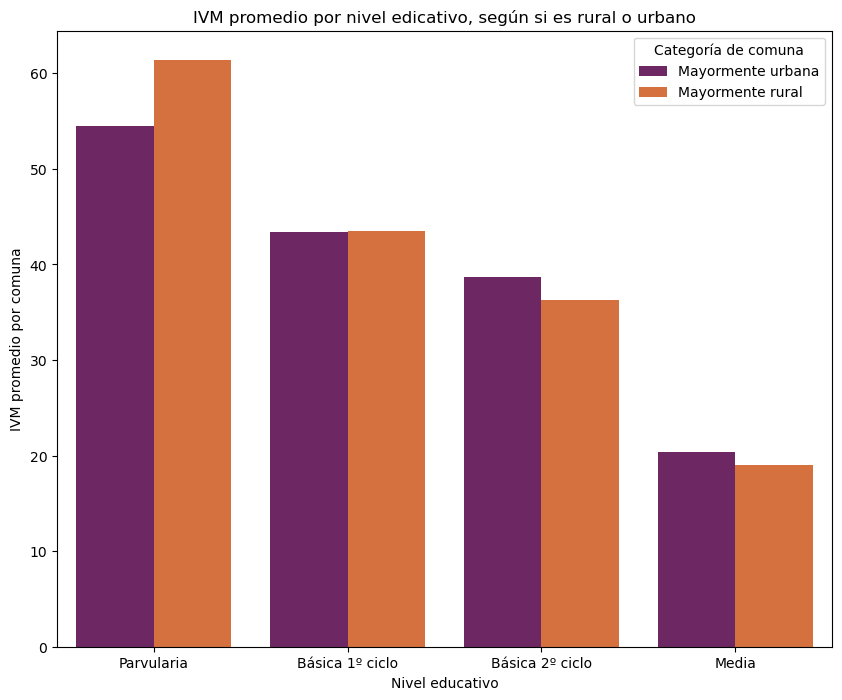

In [24]:
import numpy as np

# Comparación del IVM comunal según la comuna sea rural o urbana

agg_comunal_copy = agg_comunal.copy() # Copia por valor y no referencia, para no cambiar el original.
print("DF Comunal, primera entrada:")
display(agg_comunal_copy.head(1))

# Creamos la columna de categoría ruralidad, para poder clasificar como urbana o rural:
agg_comunal_copy["categoria_ruralidad"] = np.where(agg_comunal_copy["porcentaje_establecimientos_rurales"] >= 50,
    "Mayormente rural","Mayormente urbana")

resumen = []

# Por cada nivel, recorremos el DF y sacamos el promedio de la agrupación entre la clasificación y el IVM:
for columna_ivm, nombre_nivel in niveles_ivm_to_plot:

    datos = agg_comunal_copy[[columna_ivm, "categoria_ruralidad"]].dropna() # Limpiamos de Nulos.
    
    promedio = (
        datos.groupby("categoria_ruralidad", observed=False)[columna_ivm]
        .mean() # Sacamos el promedio aritmético
        .reset_index() # Convertimos el tipo de dato a DF
        .rename(columns={columna_ivm: "IVM promedio"})
    )
    promedio["Nivel"] = nombre_nivel
    resumen.append(promedio)

df_resumen = pd.concat(resumen, ignore_index=True) # Creamos un DF con los resumenes
print("DF df_resumen:")
display(df_resumen)

# Convertimos la col "categoria_ruralidad" en tipo category, y la ordenamos:
df_resumen["categoria_ruralidad"] = pd.Categorical(df_resumen["categoria_ruralidad"],
    categories=["Mayormente urbana", "Mayormente rural"], ordered=True)

fig, ax = plt.subplots(figsize=(10, 8)) # Graficamos
sns.barplot(
    data=df_resumen,
    x="Nivel",
    y="IVM promedio",
    hue="categoria_ruralidad",
    ax=ax,
    palette="inferno",
)
ax.set_ylabel("IVM promedio por comuna")
ax.set_xlabel("Nivel educativo")
ax.set_title("IVM promedio por nivel edicativo, según si es rural o urbano")
ax.legend(title="Categoría de comuna")

tabla_resumen = (
    df_resumen.pivot(index="Nivel", columns="categoria_ruralidad", values="IVM promedio")
    .sort_index()
)
display(tabla_resumen.round(2))

Este gráfico muestra como se comporta el IVM promedio por comunas, cuando están clasificadas entre urbanas o rurales.

Podemos observar que en el nivel de educación Parvularia hay una tendencia a un IVM promedio levemente más alto en comunas rurales, pero a diferencia que va creciendo el nivel educativo, la diferencia se vuelve más estrecha, e incluso se ve invertida en los últimos niveles. Como se mencionó en celdas anteriores, esto sucede probablemente porque estamos comparando comunalmente y, aunque hayamos planteado una pregunta con clasificación por tipo de comuna, sigue existiendo una discrepancia con lo esperado. Podemos concluir que, al menos en esta representación de los datos, la ruralidad elevada no garantiza un IVM promedio por comuna más alto.

- Realizaremos un último gráfico con la celda anterior, copiaremos la celda pero haremos una clasificación con una clasificación diferente, clasificaremos como rural a una comuna sólo si su cantidad de establecimientos rurales supera el 80%, para ver qué sucede:

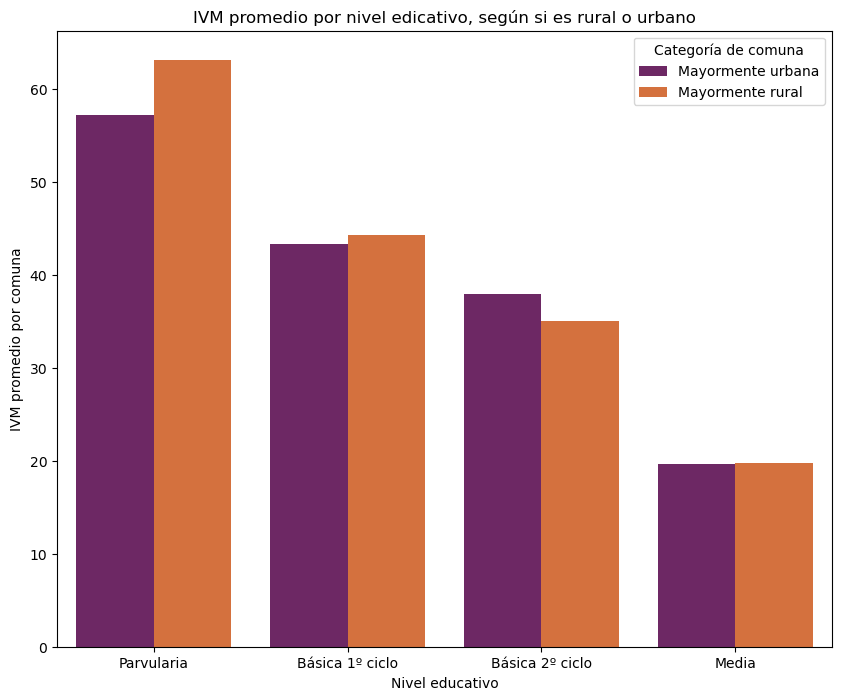

In [25]:
import numpy as np

# Comparación del IVM comunal según la comuna sea rural o urbana

agg_comunal_copy = agg_comunal.copy() # Copia por valor y no referencia, para no cambiar el original.

# Creamos la columna de categoría ruralidad, para poder clasificar como urbana o rural:
agg_comunal_copy["categoria_ruralidad"] = np.where(agg_comunal_copy["porcentaje_establecimientos_rurales"] >= 80,
    "Mayormente rural","Mayormente urbana")

resumen = []

# Por cada nivel, recorremos el DF y sacamos el promedio de la agrupación entre la clasificación y el IVM:
for columna_ivm, nombre_nivel in niveles_ivm_to_plot:

    datos = agg_comunal_copy[[columna_ivm, "categoria_ruralidad"]].dropna() # Limpiamos de Nulos.
    
    promedio = (
        datos.groupby("categoria_ruralidad", observed=False)[columna_ivm]
        .mean() # Sacamos el promedio aritmético
        .reset_index() # Convertimos el tipo de dato a DF
        .rename(columns={columna_ivm: "IVM promedio"})
    )
    promedio["Nivel"] = nombre_nivel
    resumen.append(promedio)

df_resumen = pd.concat(resumen, ignore_index=True) # Creamos un DF con los resumenes

# Convertimos la col "categoria_ruralidad" en tipo category, y la ordenamos:
df_resumen["categoria_ruralidad"] = pd.Categorical(df_resumen["categoria_ruralidad"],
    categories=["Mayormente urbana", "Mayormente rural"], ordered=True)

fig, ax = plt.subplots(figsize=(10, 8)) # Graficamos
sns.barplot(
    data=df_resumen,
    x="Nivel",
    y="IVM promedio",
    hue="categoria_ruralidad",
    ax=ax,
    palette="inferno",
)
ax.set_ylabel("IVM promedio por comuna")
ax.set_xlabel("Nivel educativo")
ax.set_title("IVM promedio por nivel edicativo, según si es rural o urbano")
ax.legend(title="Categoría de comuna")

tabla_resumen = (
    df_resumen.pivot(index="Nivel", columns="categoria_ruralidad", values="IVM promedio")
    .sort_index()
)

Obtenemos resultados similares, no hay una gran diferencia con lo anterior, el IVM no se ve excesivamente afectado. Pero el resultado cambia levemente.

Aclaraciones sobre la tarea:
- Se pidió justificar todas las decisiones realizadas. Yo no he convertido el tipo de dato a entero o numeric porque el DF principal ya tenía los tipos de datos correctos, no obtuve ningún error con ésto, así que por eso no he realizado la conversión o parseo en la mayoría de celdas. Además, al inicio en las primeras celdas se hizo la mayor parte de la limpieza del DF principal.

- Similar a lo anterior, no he hecho un raiseo de muchos posibles errores porque el dataset es muy único, si se pone otro dataset diferente no funcionaría este notebook, así que no hace falta poner resistencia a errores según la naturaleza del dataset, pero considero importante verificar que los tipos de datos estén bien, y eliminar posibles outliers o valores sin sentido del dataset, al menos para nuestro interés.